# Figuras do artigo (v1)

Rode a célula de imports (`COHORT=48m_6m`). Figuras do **corpo** do `artigo_v1.tex` estão na secção **V1** no fim deste notebook — **uma célula por figura**, com textos editáveis no topo (`TITLE`, `XLABEL`, …).

| Arquivo PDF | Célula V1 | Papel |
|-------------|-----------|--------|
| `fig_a_encoding_4cohorts.pdf` | Fig A | 4 coortes × 5 fam. × Baseline / 2v R10 / 3v rates / 3v OLS |
| `unimodal_t1_vs_ols_48m6m.pdf` | Claim T1 vs D | zoom unimodal claim |
| `roc_vol_encodings_48m6m.pdf` | ROC volume | Baseline / 2v / 3v rates / 3v OLS |
| `roc_vol_models_ols_48m6m.pdf` | ROC × 4 algos | volume D OLS (após re-run 4 modelos) |
| `four_ceilings_48m6m.pdf` | Tetos | uni T1/D/R10 + best late T1/D + all-T1/all-D |
| `soft_true_vs_false_48m6m.pdf` | Soft | soft True vs False |

`diagrama.pdf` / `nestedcv.pdf` = métodos (manuais; não regenerar aqui).

**Rebuild** (após mono 4-algo + late OLS):
```bash
PYTHONPATH=modules python modules/cohort_compare.py --include-soft --n-boot 2000
```

Células antigas (§§1–3, HM) = legado v0; não usar para o PDF v1.


In [ ]:
import json
import sys
from dataclasses import dataclass
from pathlib import Path

_MOD = Path.cwd() / "modules"
if str(_MOD) not in sys.path:
    sys.path.insert(0, str(_MOD))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import roc_auc_score, roc_curve

from ablation_analysis import (
    TIME_ORDER,
    anatomical_key,
    feature_freq_table_grouped,
    filter_ablation_config,
    filter_temporally_stable,
    parse_feature,
    pooled_auc,
    pooled_predictions,
    patient_mean_auc,
    patient_mean_predictions,
    prepare_ablation_df,
    short_anatomical_key,
    summary_with_pooled,
)
# ── editar aqui ──────────────────────────────────────────────
COHORT = "48m_6m"
BASE = Path("csvs/cohorts") / COHORT
SAVE_FIGS = True
ARTIGO_DIR = Path("Artigo 1 pgirardi")
FIG_DIR = ARTIGO_DIR / "figures"
TABLE_DIR = ARTIGO_DIR / "tables"
SUMMARY_PATH = BASE / "all_protocols_summary.csv"

COHORTS_DIR = Path("csvs/cohorts")
COMPARE_DIR = Path("csvs/cohort_comparison")
COHORTS_COMPARE = [
    c for c in (
        "36m_6m", "36m_12m",
        "48m_6m", "48m_12m",
    )
    if (COHORTS_DIR / c / "ablation_results_t1_only").is_dir()
]
# soft False entra no rebuild via CLI --include-soft; Fig A usa só COHORTS_COMPARE
COHORTS_COMPARE_SOFT = [
    c for c in ("48m_6m_soft_False",)
    if (COHORTS_DIR / c / "ablation_results_t1_only").is_dir()
]

RESULTS_MAIN_PROTOCOLS = ("t1_only", "t1_r10", "t1_r10_r21", "t1_ols")  # claim / Fig A
# revisor 2: A / B0 (Q4 abs) / B (taxas) / C (rate02) / D (OLS) — aditivo
RESULTS_ABCD_PROTOCOLS = (
    "t1_only", "t1_d21_d32", "t1_r10", "t1_r10_r21", "t1_rate02", "t1_ols",
)
RESULTS_SUPP_PROTOCOLS = (
    "t1_only", "t1_d21_d32", "t1_d21_d32_global",
    "t1_r10_r21", "t1_rate02", "t1_ols",
    "clinica", "clinica+img_t1",
)
RESULTS_TOP_N = 3
RESULTS_TOP_GROUP = ("task", "protocol", "with_combat")

MOD_ORDER = ["vol", "shape", "texture", "disp", "firstorder"]
MODEL_ORDER = ["svm", "rf", "elasticnet", "xgb"]
ROC_COLORS = {
    "svm": "#4477AA", "rf": "#EE6677", "elasticnet": "#228833", "xgb": "#CCBB44",
}
N_BOOT_AUC = 2000
STAB_MIN_PCT = 70
STAB_MIN_TIMEPOINTS = 0

MOD_LABELS = {
    "vol": "Volume", "shape": "Shape", "texture": "Texture",
    "disp": "DVF", "firstorder": "First-order",
}
MODEL_LABELS = {
    "svm": "SVM", "rf": "RF", "elasticnet": "Elastic-Net", "xgb": "XGBoost",
}

PROTOCOL_ROOTS = {
    "t1_only": BASE / "ablation_results_t1_only",
    "t1_d21": BASE / "ablation_results_d21",
    "t1_d21_d32": BASE / "ablation_results_d21d32",
    "t1_r10": BASE / "ablation_results_r10",
    "t1_r10_r21": BASE / "ablation_results_r10r21",
    "t1_rate02": BASE / "ablation_results_rate02",
    "t1_ols": BASE / "ablation_results_ols",
    "t1_d21_d32_global": BASE / "ablation_results_leaky_d21d32",
    "clinica": BASE / "ablation_results_clinic",
    "clinica+img_t1": BASE / "ablation_results_clinic_img_t1_only",
}
LATE_FUSION_RESULTS_ROOT = BASE / "ablation_results_late_fusion"


@dataclass(frozen=True)
class CFG:
    selection_mode: str = "l1_stable"
    with_combat: bool = False
    task_primary: str = "smci_pmci"
    task_sanity: str = "cn_ad"
    model_primary: str = "svm"
    modality_primary: str = "vol"
    model_sanity: str = "svm"
    modality_sanity: str = "vol"


CFG = CFG()
TASK_LABELS = {"cn_ad": "CN × AD", "smci_pmci": "sMCI × pMCI"}
CM_LABELS = {
    "cn_ad": ("CN", "AD"),
    "smci_pmci": ("sMCI", "pMCI"),
}


def _csv(mod_dir: Path, stem: str, sel: str) -> Path:
    for name in (f"{stem}_{sel}.csv", f"{stem}.csv"):
        p = mod_dir / name
        if p.is_file():
            return p
    raise FileNotFoundError(f"{stem} ausente em {mod_dir}")


def _iter_mod_dirs(root: Path, protocol: str):
    for mod in MOD_ORDER:
        d = root / mod
        if d.is_dir():
            yield d
    # sanity CN×AD só no encoding Q4
    if protocol == "t1_d21_d32":
        cn = root / "vol_cn_ad"
        if cn.is_dir():
            yield cn


def load_summary(protocol: str, sel: str = CFG.selection_mode) -> pd.DataFrame:
    root = PROTOCOL_ROOTS[protocol]
    frames = []
    for d in _iter_mod_dirs(root, protocol):
        try:
            frames.append(pd.read_csv(_csv(d, "ablation_summary", sel)))
        except FileNotFoundError:
            pass
    if not frames:
        raise FileNotFoundError(f"sem summary em {root}")
    return pd.concat(frames, ignore_index=True)


def load_ablation(protocol: str, sel: str = CFG.selection_mode) -> pd.DataFrame:
    root = PROTOCOL_ROOTS[protocol]
    frames = []
    for d in _iter_mod_dirs(root, protocol):
        try:
            frames.append(pd.read_csv(_csv(d, "ablation_results_all", sel)))
        except FileNotFoundError:
            pass
    if not frames:
        raise FileNotFoundError(f"sem ablation_results_all em {root}")
    return prepare_ablation_df(pd.concat(frames, ignore_index=True))


def save_fig(fig, name: str) -> None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    path = FIG_DIR / f"{name}.pdf"
    if SAVE_FIGS:
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Salvo:", path)
    plt.show()
    plt.close(fig)


ablation_t1 = load_ablation("t1_only")
ablation_q4 = load_ablation("t1_d21_d32")  # B0 sensibilidade
ablation_r10 = load_ablation("t1_r10")
ablation_r10r21 = load_ablation("t1_r10_r21")
ablation_ols = load_ablation("t1_ols")
try:
    ablation_d21 = load_ablation("t1_d21")
except FileNotFoundError as e:
    ablation_d21 = pd.DataFrame()
    print("t1_d21: sem CSV —", e)
summary_t1 = summary_with_pooled(ablation_t1)
summary_q4 = summary_with_pooled(ablation_q4)
summary_all = pd.read_csv(SUMMARY_PATH) if SUMMARY_PATH.is_file() else pd.DataFrame()
print(f"cohort={COHORT} | selection={CFG.selection_mode} | combat={CFG.with_combat}")
print(f"ablation_t1: {len(ablation_t1)} linhas | mods={sorted(ablation_t1['modality'].astype(str).unique())}")
print(f"ablation_d21: {len(ablation_d21)} linhas | mods={sorted(ablation_d21['modality'].astype(str).unique()) if not ablation_d21.empty else []}")
print(f"ablation_q4: {len(ablation_q4)} linhas | mods={sorted(ablation_q4['modality'].astype(str).unique())}")
_cn = ablation_q4.loc[ablation_q4["task"].astype(str) == "cn_ad"]
if _cn.empty:
    print("cn_ad: sem dados em vol_cn_ad")
else:
    print(
        "cn_ad mods × models:",
        sorted(_cn.groupby(["modality", "model_key"]).size().index.tolist()),
    )


cohort=48m_6m | selection=l1_stable | combat=False
ablation_t1: 1000 linhas | mods=['disp', 'firstorder', 'shape', 'texture', 'vol']
ablation_d21: 850 linhas | mods=['disp', 'firstorder', 'shape', 'texture', 'vol']
ablation_q4: 2000 linhas | mods=['disp', 'firstorder', 'shape', 'texture', 'vol']
cn_ad mods × models: [('disp', 'elasticnet'), ('disp', 'rf'), ('disp', 'svm'), ('disp', 'xgb'), ('firstorder', 'elasticnet'), ('firstorder', 'rf'), ('firstorder', 'svm'), ('firstorder', 'xgb'), ('shape', 'elasticnet'), ('shape', 'rf'), ('shape', 'svm'), ('shape', 'xgb'), ('texture', 'elasticnet'), ('texture', 'rf'), ('texture', 'svm'), ('texture', 'xgb'), ('vol', 'elasticnet'), ('vol', 'rf'), ('vol', 'svm'), ('vol', 'xgb')]


## Consolidação (1 cohort)

Gera/atualiza `all_protocols_summary.csv` (T1, D21, Q4, late, leaky).


In [2]:
CONFIG_COLS = ["task", "modality", "model_key", "with_combat", "selection_mode"]
CONSOLIDATION_PROTOCOL_ROOTS = {
    "t1_only": BASE / "ablation_results_t1_only",
    "t1_d21": BASE / "ablation_results_d21",
    "t1_d21_d32": BASE / "ablation_results_d21d32",
    "t1_r10": BASE / "ablation_results_r10",
    "t1_r10_r21": BASE / "ablation_results_r10r21",
    "t1_rate02": BASE / "ablation_results_rate02",
    "t1_ols": BASE / "ablation_results_ols",
    "late_scan": BASE / "ablation_results_late_fusion",
    "t1_d21_d32_global": BASE / "ablation_results_leaky_d21d32",
    "clinica": BASE / "ablation_results_clinic",
    "clinica+img_t1": BASE / "ablation_results_clinic_img_t1_only",
}


def _summary_files(root: Path) -> list[Path]:
    def _ok(p: Path) -> bool:
        blob = f"{p.parent.name}/{p.stem}".lower()
        return "backup" not in blob and "_cn_ad" not in blob

    files = [f for f in root.glob("*/ablation_summary.csv") if _ok(f)]
    files += [
        f for f in root.glob("*summary*.csv")
        if not f.name.startswith("all_") and _ok(f)
    ]
    return files


def build_all_protocols_summary() -> pd.DataFrame:
    frames = []
    for proto, root in CONSOLIDATION_PROTOCOL_ROOTS.items():
        if not root.is_dir():
            continue
        for f in _summary_files(root):
            df = pd.read_csv(f)
            if root.name == "ablation_results_late_fusion":
                row_proto = f"late__{f.parent.name}"
            else:
                row_proto = proto
            df.insert(0, "protocol", row_proto)
            df["source_file"] = str(f.relative_to(BASE))
            df["source_mtime"] = pd.Timestamp(f.stat().st_mtime, unit="s")
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    master = pd.concat(frames, ignore_index=True)
    keys = ["protocol"] + [c for c in CONFIG_COLS if c in master.columns]
    master = master.sort_values("source_mtime").drop_duplicates(keys, keep="last")
    front = ["protocol", *CONFIG_COLS, "auc_patient_mean", "auc_pooled", "auc_mean", "auc_std", "n_features_mean"]
    front = [c for c in front if c in master.columns]
    master = master[front + [c for c in master.columns if c not in front]]
    rank_col = "auc_patient_mean" if "auc_patient_mean" in master.columns else "auc_pooled"
    return master.sort_values([rank_col, "protocol"], ascending=[False, True]).reset_index(drop=True)


summary_all = build_all_protocols_summary()
if summary_all.empty:
    print(f"{SUMMARY_PATH.name} vazio — rode ablations antes")
else:
    summary_all.to_csv(SUMMARY_PATH, index=False)
    print(f"Salvo: {SUMMARY_PATH} | {len(summary_all)} linhas")
    print(summary_all.groupby("protocol").size().rename("linhas").to_string())
    show_cols = ["protocol"] + [c for c in CONFIG_COLS if c in summary_all.columns]
    show_cols += [c for c in (
        "auc_patient_mean", "auc_pooled", "auc_mean", "auc_std", "n_features_mean"
    ) if c in summary_all.columns]
    display(summary_all[show_cols].head(20))


Salvo: csvs/cohorts/48m_6m/all_protocols_summary.csv | 317 linhas
protocol
clinica                                                                                           1
clinica+img_t1                                                                                    1
late__t1_d21d32_disp__t1_d21d32_firstorder                                                        1
late__t1_d21d32_disp__t1_firstorder                                                               1
late__t1_d21d32_shape__t1_d21d32_disp                                                             1
late__t1_d21d32_shape__t1_d21d32_disp__t1_d21d32_firstorder                                       1
late__t1_d21d32_shape__t1_d21d32_disp__t1_firstorder                                              1
late__t1_d21d32_shape__t1_d21d32_firstorder                                                       1
late__t1_d21d32_shape__t1_d21d32_texture                                                          1
late__t1_d21d32_shape__t1

,protocol,task,modality,model_key,with_combat,selection_mode,auc_patient_mean,auc_pooled,auc_mean,auc_std,n_features_mean
0,t1_d21_d32,cn_ad,shape,elasticnet,False,l1_stable,0.904027,0.895864,0.901072,0.035916,10.66
1,t1_d21_d32,cn_ad,shape,svm,False,l1_stable,0.901007,0.894099,0.896352,0.034980,4.12
2,t1_d21_d32,cn_ad,shape,rf,False,l1_stable,0.881879,0.866449,0.870105,0.043044,4.12
3,t1_d21_d32,cn_ad,vol,elasticnet,False,l1_stable,0.881611,0.872150,0.878354,0.036864,10.82
4,t1_d21_d32,cn_ad,vol,svm,False,l1_stable,0.881409,0.872736,0.875382,0.038770,11.10
5,t1_d21_d32,cn_ad,shape,xgb,False,l1_stable,0.878255,0.859193,0.865977,0.040410,4.12
6,clinica+img_t1,smci_pmci,vol,svm,False,l1_stable,0.865868,0.858131,0.868879,0.058742,7.04
7,t1_d21_d32,cn_ad,vol,rf,False,l1_stable,0.852349,0.843268,0.845947,0.044643,11.10
8,t1_d21_d32,cn_ad,vol,xgb,False,l1_stable,0.851812,0.826568,0.842853,0.041170,11.10
9,clinica,smci_pmci,clinical,svm,False,none,0.839612,0.828733,0.839258,0.065012,5.00


## 1. Protocolos no primary (âncora A)

Shape T1 (teto) vs Shape/Vol Q4, late 3 specs, leaky vol. SVM · `COHORT`.
Dose de tempo (T1 / D21 / Q4, 5 fam.) → §2.1. Stats FDR: `7_stats`.


Âncora A | Protocolos | 48m_6m | smci_pmci | svm | no ComBat


,label,protocol,modality,auc_patient_mean,auc_std,auc_pooled,n_features_mean
0,Shape T1,t1_only,shape,0.7115,0.0812,0.6978,1.22
1,Shape Q4,t1_d21_d32,shape,0.7213,0.0791,0.7058,4.56
2,Vol T1,t1_only,vol,0.7559,0.0814,0.7466,2.04
3,Vol Q4,t1_d21_d32,vol,0.7630,0.0683,0.7448,9.32
4,Late T1,late__t1_vol__t1_shape__t1_texture__t1_disp__t...,late__t1_vol__t1_shape__t1_texture__t1_disp__t...,0.7718,0.0704,0.7603,9.60
5,Late Q4,late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d3...,late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d3...,0.7872,0.0761,0.7709,31.18
6,Late ancora,late__t1_shape__t1_d21d32_vol__t1_d21d32_textu...,late__t1_shape__t1_d21d32_vol__t1_d21d32_textu...,0.8232,0.0692,0.8104,28.64
7,Leaky Q4 vol,t1_d21_d32_global,vol,0.7702,0.0750,0.7533,11.00


CSV: csvs/cohorts/48m_6m/protocol_compare_primary.csv
Salvo: artigo/figures/protocol_compare_primary.pdf


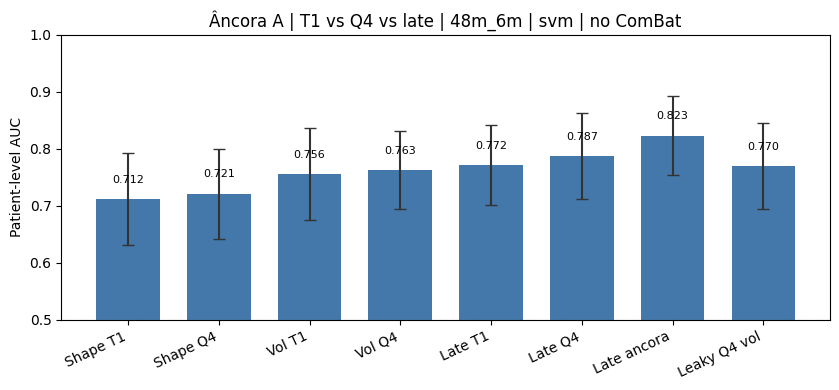

In [3]:
# Âncora A — T1 vs Q4 vs late vs leaky (COHORT / CFG)
LATE_ALL_T1 = "late__t1_vol__t1_shape__t1_texture__t1_disp__t1_firstorder"
LATE_ALL_Q4 = (
    "late__t1_d21d32_vol__t1_d21d32_shape__t1_d21d32_texture"
    "__t1_d21d32_disp__t1_d21d32_firstorder"
)
LATE_ANCORA = (
    "late__t1_shape__t1_d21d32_vol__t1_d21d32_texture"
    "__t1_d21d32_disp__t1_d21d32_firstorder"
)
PROTOCOL_COMPARE = (
    ("t1_only", "shape", "Shape T1"),
    ("t1_d21_d32", "shape", "Shape Q4"),
    ("t1_only", "vol", "Vol T1"),
    ("t1_d21_d32", "vol", "Vol Q4"),
    (LATE_ALL_T1, LATE_ALL_T1, "Late T1"),
    (LATE_ALL_Q4, LATE_ALL_Q4, "Late Q4"),
    (LATE_ANCORA, LATE_ANCORA, "Late ancora"),
    ("t1_d21_d32_global", "vol", "Leaky Q4 vol"),
)
BACKUP_RE = r"backup|_cn_ad"

rows = []
if summary_all.empty:
    print("summary_all vazio — rode consolidação antes")
else:
    s = summary_all.copy()
    if "with_combat" in s.columns:
        s["with_combat"] = s["with_combat"].map(
            lambda x: str(x).strip().lower() in ("1", "true", "yes")
        )
    if "source_file" in s.columns:
        s = s.loc[
            ~s["source_file"].astype(str).str.contains(BACKUP_RE, regex=True, na=False)
        ]

    for proto, mod, label in PROTOCOL_COMPARE:
        hit = s.query(
            "protocol == @proto and task == @CFG.task_primary "
            "and modality == @mod and model_key == @CFG.model_primary "
            "and with_combat == False"
        )
        if hit.empty:
            print(f"MISS: {label} ({proto}/{mod})")
            continue
        r = hit.iloc[0]
        rows.append({
            "label": label,
            "protocol": proto,
            "modality": mod,
            "auc_patient_mean": float(r["auc_patient_mean"]),
            "auc_std": float(r["auc_std"]) if pd.notna(r.get("auc_std")) else float("nan"),
            "auc_pooled": float(r["auc_pooled"]) if "auc_pooled" in r and pd.notna(r["auc_pooled"]) else float("nan"),
            "n_features_mean": r.get("n_features_mean"),
            "source_file": r.get("source_file", ""),
        })

    proto_cmp = pd.DataFrame(rows)
    if proto_cmp.empty:
        print("Nenhuma linha protocol compare — falta T1/Q4/late?")
    else:
        order = [lab for _, _, lab in PROTOCOL_COMPARE if lab in set(proto_cmp["label"])]
        proto_cmp["label"] = pd.Categorical(proto_cmp["label"], categories=order, ordered=True)
        proto_cmp = proto_cmp.sort_values("label").reset_index(drop=True)

        print(f"Âncora A | Protocolos | {COHORT} | {CFG.task_primary} | {CFG.model_primary} | no ComBat")
        display(proto_cmp.drop(columns=["source_file"], errors="ignore").round(4))

        out_csv = BASE / "protocol_compare_primary.csv"
        proto_cmp.to_csv(out_csv, index=False)
        print(f"CSV: {out_csv}")

        fig, ax = plt.subplots(figsize=(8.5, 4))
        x = np.arange(len(proto_cmp))
        ax.bar(
            x,
            proto_cmp["auc_patient_mean"],
            yerr=proto_cmp["auc_std"],
            capsize=4,
            color="#4477AA",
            ecolor="#333333",
            width=0.7,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(proto_cmp["label"].astype(str), rotation=25, ha="right")
        ax.set_ylabel("Patient-level AUC")
        ax.set_ylim(0.5, 1.0)
        ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
        ax.set_title(
            f"Âncora A | T1 vs Q4 vs late | {COHORT} | {CFG.model_primary} | no ComBat"
        )
        for i, v in enumerate(proto_cmp["auc_patient_mean"]):
            ax.text(i, min(0.99, v + 0.025), f"{v:.3f}", ha="center", va="bottom", fontsize=8)
        plt.tight_layout()
        save_fig(fig, "protocol_compare_primary")
        plt.show()


## 2. Heatmaps, ROC, estabilidade — T1 (âncora) + Q4 / CN×AD

Heatmap e ROC no **baseline** (`t1_only`); teto unimodal = **shape**. Sanity `cn_ad` no encoding Q4 (`vol_cn_ad`).


In [4]:
def filter_cfg(df: pd.DataFrame, *, task: str, combat: bool | None = None) -> pd.DataFrame:
    """Filtra selection_mode / ComBat / task (CFG)."""
    out = df[df["selection_mode"].astype(str) == CFG.selection_mode].copy()
    combat = CFG.with_combat if combat is None else combat
    out = out[out["with_combat"] == combat]
    out = out[out["task"].astype(str) == task]
    return out


def _patient_mean_cell(df: pd.DataFrame, *, task: str, modality: str, model: str) -> tuple[float, float]:
    """Patient-level AUC (subject-averaged OOF) + bootstrap SD (mesmo estimador ROC)."""
    sub = filter_ablation_config(
        df, task=task, modality=modality, model_key=model,
        with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
    )
    y, s = patient_mean_predictions(sub)
    auc = float(roc_auc_score(y, s))
    sd = bootstrap_auc_std(y, s)
    return auc, sd



def plot_heatmap(df, task: str, *, title: str, fname: str, vmin=0.5, vmax=1.0):
    """Heatmap patient-level AUC ± bootstrap SD (ablation raw, não summary)."""
    sub = filter_cfg(df, task=task)
    mods = [m for m in MOD_ORDER if m in sub["modality"].astype(str).unique()]
    models = [m for m in MODEL_ORDER if m in sub["model_key"].astype(str).unique()]
    auc_w = pd.DataFrame(index=models, columns=mods, dtype=float)
    sd_w = pd.DataFrame(index=models, columns=mods, dtype=float)
    for model in models:
        for mod in mods:
            try:
                auc, sd = _patient_mean_cell(df, task=task, modality=mod, model=model)
            except (ValueError, KeyError) as e:
                print(f"heatmap skip {task}/{mod}/{model}: {e}")
                continue
            auc_w.loc[model, mod] = auc
            sd_w.loc[model, mod] = sd
    if auc_w.size == 0 or not mods or not models:
        print(f"heatmap skip {task}: sem dados (mods={mods}, models={models})")
        return
    auc_w = auc_w.rename(index=MODEL_LABELS, columns=MOD_LABELS)
    sd_w = sd_w.rename(index=MODEL_LABELS, columns=MOD_LABELS)
    annot = np.asarray(
        [
            ["" if pd.isna(p) else f"{p:.3f}±{s:.2f}" for p, s in zip(auc_w.iloc[i], sd_w.iloc[i])]
            for i in range(len(auc_w))
        ],
        dtype=object,
    ).reshape(auc_w.shape)
    fig, ax = plt.subplots(figsize=(6.2, 4.2))
    sns.heatmap(auc_w.astype(float), annot=annot, fmt="", cmap="YlOrRd",
                vmin=vmin, vmax=vmax, ax=ax, cbar_kws={"label": "Patient-level AUC"})
    ax.set_xlabel("Modality")
    ax.set_ylabel("Classifier")
    ax.set_title(title)
    plt.tight_layout()
    save_fig(fig, fname)



def _interp_tpr(fpr, tpr, grid: np.ndarray) -> np.ndarray:
    return np.interp(grid, fpr, tpr, left=0.0, right=1.0)



def roc_fold_bands(sub: pd.DataFrame, fpr_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """TPR médio ± SD entre avaliações externas (fold × repeat)."""
    tpr_rows: list[np.ndarray] = []
    for _, row in sub.iterrows():
        y = np.asarray(json.loads(row["test_y_true"]), dtype=int)
        s = np.asarray(json.loads(row["test_scores"]), dtype=float)
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, s)
        tpr_rows.append(_interp_tpr(fpr, tpr, fpr_grid))
    if not tpr_rows:
        raise ValueError("Nenhum fold com duas classes")
    stack = np.vstack(tpr_rows)
    return stack.mean(axis=0), stack.std(axis=0, ddof=0)



def bootstrap_auc_std(y, scores, *, n_boot: int = N_BOOT_AUC, seed: int = 0) -> float:
    """SD da AUC (patient-level / subject-averaged OOF ou pooled) por bootstrap nas predições agregadas."""
    y = np.asarray(y, dtype=int)
    scores = np.asarray(scores, dtype=float)
    rng = np.random.default_rng(seed)
    aucs: list[float] = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), size=len(y))
        yb, sb = y[idx], scores[idx]
        if len(np.unique(yb)) < 2:
            continue
        aucs.append(float(roc_auc_score(yb, sb)))
    if not aucs:
        return float("nan")
    return float(np.std(aucs, ddof=0))



def plot_roc_models(
    df,
    task: str,
    mod: str,
    *,
    title: str,
    fname: str,
    models: list[str] | None = None,
    score_agg: str = "patient_mean",
):
    """ROC: faixa = ±SD TPR entre folds; legenda = patient-level AUC ± bootstrap SD."""
    agg_fn = patient_mean_predictions if score_agg == "patient_mean" else pooled_predictions
    models = models or MODEL_ORDER
    fpr_grid = np.linspace(0, 1, 101)
    fig, ax = plt.subplots(figsize=(6, 5.5))
    for i, model in enumerate(models):
        try:
            sub = filter_ablation_config(
                df, task=task, modality=mod, model_key=model,
                with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
            )
        except ValueError as e:
            print(f"ROC skip {model}: {e}")
            continue
        tpr_m, tpr_s = roc_fold_bands(sub, fpr_grid)
        y, scores = agg_fn(sub)
        auc = float(roc_auc_score(y, scores))
        sd = bootstrap_auc_std(y, scores, seed=100 + i)
        color = ROC_COLORS.get(model, f"C{i}")
        ax.fill_between(
            fpr_grid,
            np.clip(tpr_m - tpr_s, 0, 1),
            np.clip(tpr_m + tpr_s, 0, 1),
            color=color, alpha=0.22, linewidth=0,
        )
        model_label = MODEL_LABELS.get(model, model)
        ax.plot(fpr_grid, tpr_m, color=color, lw=2, label=f"{model_label}  {auc:.3f}±{sd:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.text(
        0.03, 0.97, TASK_LABELS.get(task, task), transform=ax.transAxes,
        va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="0.85", edgecolor="0.6"),
    )
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate (TPR)")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=10, title="Patient-level AUC ± SD")
    ax.set_aspect("equal")
    plt.tight_layout()
    save_fig(fig, fname)



def _time_order_from_sub(sub: pd.DataFrame) -> tuple[str, ...]:
    tokens: set[str] = set()
    for _, row in sub.iterrows():
        for feat in json.loads(row["selected_features"]):
            p = parse_feature(feat)
            if p:
                tokens.add(p[1])
    if tokens & {"D21", "D31", "D32"}:
        return ("T1", "D21", "D31", "D32")
    if tokens & {"D21", "D31", "SLOPE"}:
        return ("T1", "D21", "D31", "SLOPE")
    return tuple(t for t in TIME_ORDER if t in tokens) or TIME_ORDER



def _fold_flags(sub: pd.DataFrame, feature_group: str, time_order: tuple[str, ...]) -> dict[str, np.ndarray]:
    """Por fold: seleção 0/1 (any + cada visita/representação)."""
    sub = prepare_ablation_df(sub)
    any_f = []
    by_time = {t: [] for t in time_order}
    for _, row in sub.iterrows():
        times: set[str] = set()
        for feat in json.loads(row["selected_features"]):
            if anatomical_key(feat) != feature_group:
                continue
            parsed = parse_feature(feat)
            if parsed:
                times.add(parsed[1])
        any_f.append(int(bool(times)))
        for t in time_order:
            by_time[t].append(int(t in times))
    return {"any": np.asarray(any_f), **{t: np.asarray(v) for t, v in by_time.items()}}



def _fmt_ms(mean, std, digits: int = 3) -> str:
    if pd.isna(mean):
        return ""
    if std is None or pd.isna(std):
        return f"{float(mean):.{digits}f}"
    return f"{float(mean):.{digits}f}±{float(std):.{digits}f}"



def build_stability_table(
    df,
    task: str,
    model: str,
    *,
    modalities: list[str] | None = None,
    min_pct: int = STAB_MIN_PCT,
    min_timepoints: int = STAB_MIN_TIMEPOINTS,
) -> pd.DataFrame:
    """Tabela longa: modalidade × atributo estável (≥min_pct em ≥min_timepoints tempos)."""
    modalities = modalities or MOD_ORDER
    rows: list[dict] = []
    for mod in modalities:
        try:
            sub = filter_ablation_config(
                df, task=task, modality=mod, model_key=model,
                with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
            )
        except ValueError:
            continue
        grp = feature_freq_table_grouped(sub, min_coverage=0.0)
        grp = filter_temporally_stable(grp, min_pct=min_pct, min_timepoints=min_timepoints)
        if grp.empty:
            continue
        time_order = _time_order_from_sub(sub)
        for _, r in grp.iterrows():
            flags = _fold_flags(sub, r["feature_group"], time_order)
            row = {
                "modality": mod,
                "feature": r["feature_short"],
                "coverage_pct": r["coverage_pct"],
                "sd_fold": float(flags["any"].std(ddof=0)),
            }
            for t in time_order:
                col = f"pct_{t}"
                if col in r.index:
                    row[col] = r[col]
                    row[f"sd_{t}"] = float(flags[t].std(ddof=0))
            rows.append(row)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ["modality", "coverage_pct", "feature"], ascending=[True, False, True],
    ).reset_index(drop=True)


METRIC_PAIRS = (
    ("auc_mean", "auc_std", "auc"),
    ("accuracy_mean", "accuracy_std", "acc"),
    ("bal_acc_mean", "bal_acc_std", "bacc"),
    ("mcc_mean", "mcc_std", "mcc"),
    ("f1_pos_mean", "f1_pos_std", "f1"),
    ("sens_pos_mean", "sens_pos_std", "sens"),
    ("spec_neg_mean", "spec_neg_std", "spec"),
    ("auc_pr_mean", "auc_pr_std", "auc_pr"),
)
RESULT_ID_COLS = ("protocol", "task", "modality", "model_key", "with_combat", "selection_mode")


Âncora A | t1_only | tasks: ['smci_pmci']
mods t1: ['disp', 'firstorder', 'shape', 'texture', 'vol']
mods q4: ['disp', 'firstorder', 'shape', 'texture', 'vol']
Salvo: artigo/figures/heatmap_smci_pmci_t1.pdf


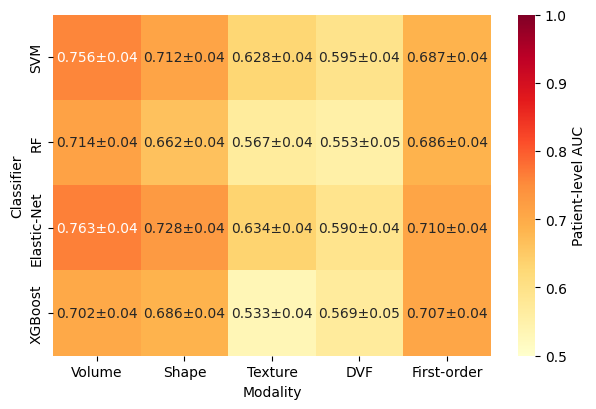

Salvo: artigo/figures/heatmap_smci_pmci_q4.pdf


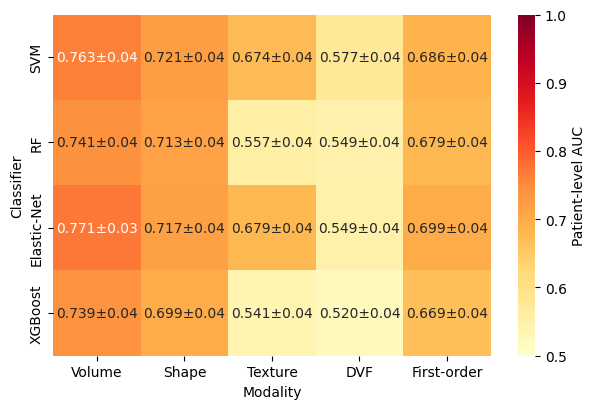

Salvo: artigo/figures/heatmap_cn_ad.pdf


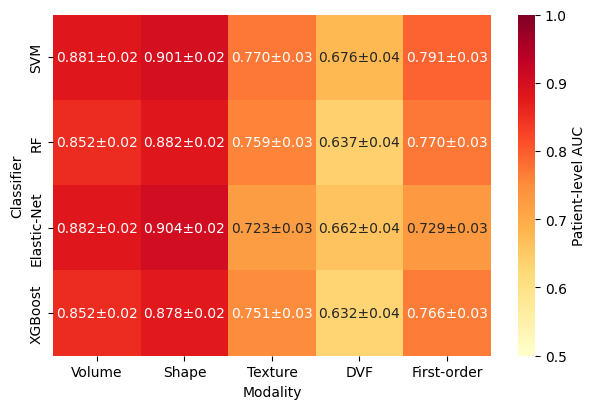

Salvo: artigo/figures/roc_smci_pmci_t1_shape.pdf


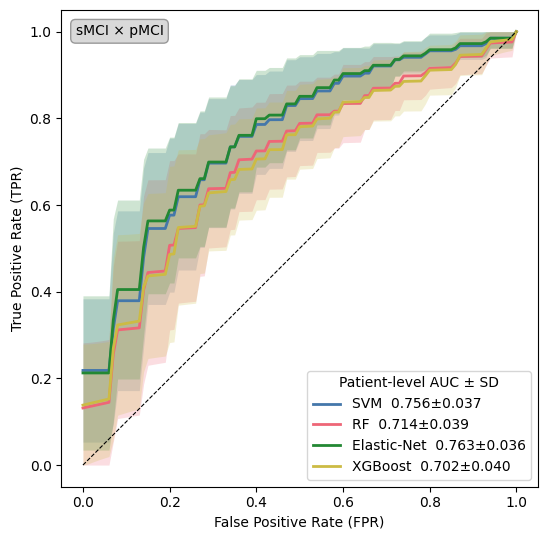

Salvo: artigo/figures/roc_smci_pmci_q4_shape.pdf


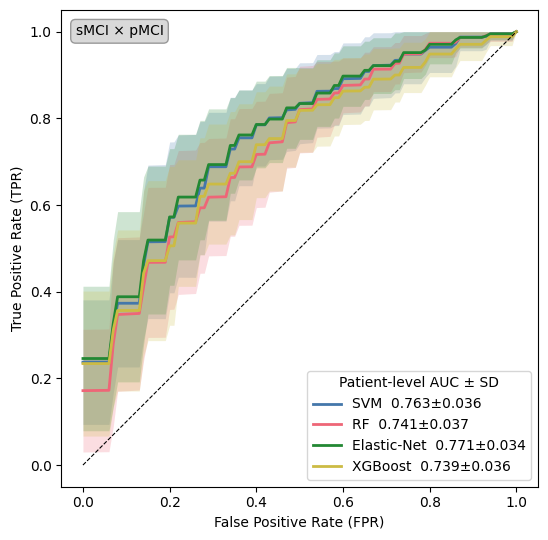

Salvo: artigo/figures/roc_cn_ad.pdf


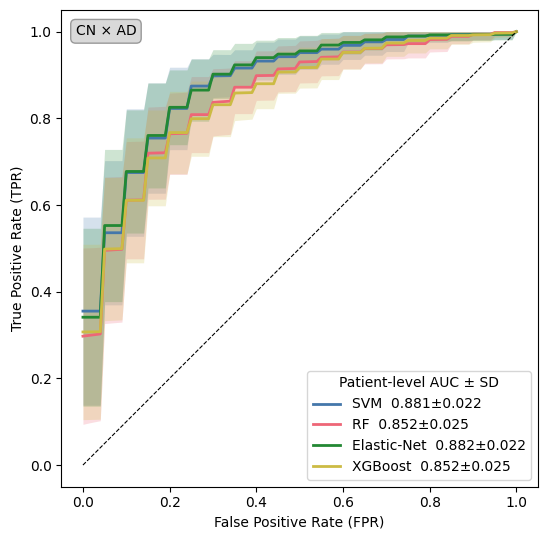

Estabilidade (t1_only) | sMCI × pMCI | svm | ≥70%


In [5]:
# Âncora A — figuras T1 + sanity cn_ad (Q4 vol)
_tag = f"{CFG.selection_mode}_" + ("combat" if CFG.with_combat else "nocombat")
print("Âncora A | t1_only | tasks:", sorted(ablation_t1["task"].astype(str).unique()))
print("mods t1:", sorted(ablation_t1["modality"].astype(str).unique()))
print("mods q4:", sorted(ablation_q4["modality"].astype(str).unique()))

plot_heatmap(
    ablation_t1, CFG.task_primary,
    title="", fname=f"heatmap_{CFG.task_primary}_t1",
)
plot_heatmap(
    ablation_q4, CFG.task_primary,
    title="", fname=f"heatmap_{CFG.task_primary}_q4",
)
try:
    plot_heatmap(
        ablation_q4, CFG.task_sanity,
        title="", fname=f"heatmap_{CFG.task_sanity}",
    )
except Exception as e:
    print(f"heatmap cn_ad skip: {e}")

plot_roc_models(
    ablation_t1, CFG.task_primary, CFG.modality_primary,
    title="", fname=f"roc_{CFG.task_primary}_t1_shape", score_agg="patient_mean",
)
plot_roc_models(
    ablation_q4, CFG.task_primary, CFG.modality_primary,
    title="", fname=f"roc_{CFG.task_primary}_q4_shape", score_agg="patient_mean",
)
try:
    plot_roc_models(
        ablation_q4, CFG.task_sanity, CFG.modality_sanity,
        title="", fname=f"roc_{CFG.task_sanity}", score_agg="patient_mean",
    )
except Exception as e:
    print(f"roc cn_ad skip: {e} — pasta vol_cn_ad")

stab_tbl = build_stability_table(ablation_t1, CFG.task_primary, CFG.model_primary)
print(
    f"Estabilidade (t1_only) | {TASK_LABELS[CFG.task_primary]} | {CFG.model_primary} "
    f"| ≥{STAB_MIN_PCT}%"
)



## 2.1 Dose de tempo — T1 vs duas vs três visitas

SVM · `smci_pmci` · `COHORT`. Mesmos IDs; só muda o encoding (`t1_only` / `t1_d21` / `t1_d21_d32`).

Sem late / leaky nesta figura. Heatmaps 4 modelos ficam T1 e Q4 (§2). `t1_d21` vazio até o bash `TWO_VISIT`.

Dose de tempo | 48m_6m | smci_pmci | svm | no ComBat


encoding,Baseline,2 imagens,3 imagens
mod_label,,,
Volume,0.756±0.037,0.740±0.038,0.763±0.035
Shape,0.712±0.039,0.716±0.039,0.721±0.039
Texture,0.628±0.042,0.671±0.040,0.674±0.040
DVF,0.595±0.042,0.548±0.043,0.577±0.045
First-order,0.687±0.040,0.691±0.039,0.686±0.040


Salvo: artigo/figures/encoding_t1_d21_q4.pdf


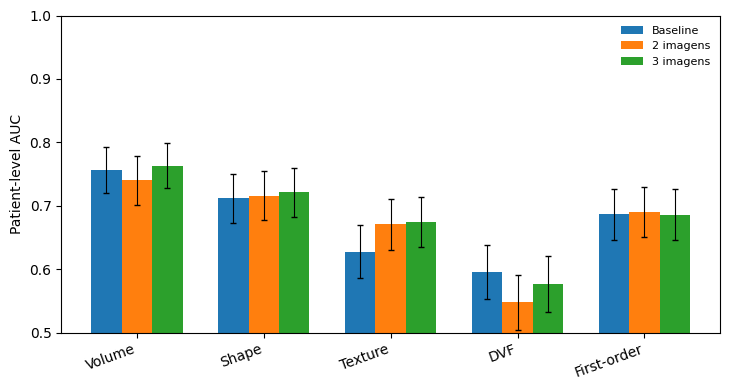

Salvo: artigo/figures/roc_smci_pmci_encodings_shape.pdf


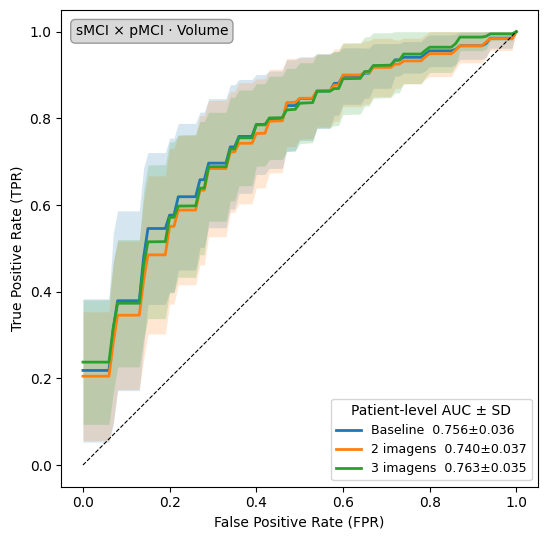

Salvo: artigo/figures/roc_smci_pmci_encodings_vol.pdf


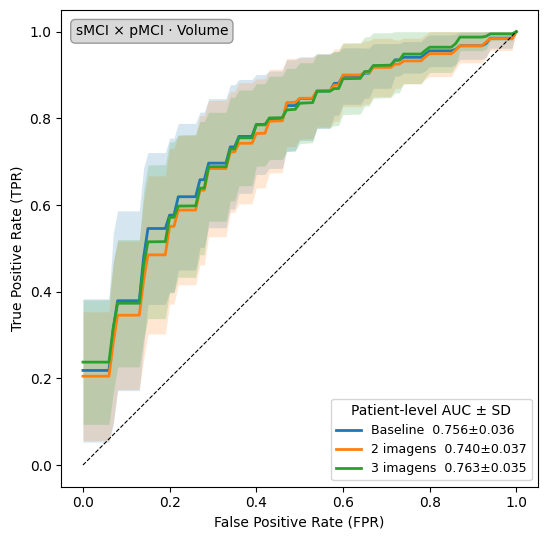

In [ ]:
ENC_SPECS = (
    ("t1_only", "Baseline", ablation_t1),
    ("t1_d21", "2 imagens", ablation_d21),
    ("t1_d21_d32", "3 imagens", ablation_q4),
)
ENC_COLORS = {"T1": "#4477AA", "T1+D21": "#CCBB44", "T1+D21+D32": "#EE6677"}

rows = []
for proto, lab, df in ENC_SPECS:
    if df is None or df.empty:
        print(f"skip {proto}: vazio")
        continue
    for mod in MOD_ORDER:
        try:
            auc, sd = _patient_mean_cell(
                df, task=CFG.task_primary, modality=mod, model=CFG.model_primary,
            )
        except (ValueError, KeyError) as e:
            print(f"skip {lab}/{mod}: {e}")
            continue
        rows.append({"encoding": lab, "protocol": proto, "modality": mod, "auc": auc, "sd": sd})

enc_tbl = pd.DataFrame(rows)
if enc_tbl.empty:
    print("encoding 3 vias: sem linhas")
else:
    enc_tbl["mod_label"] = enc_tbl["modality"].map(MOD_LABELS)
    annot = enc_tbl.assign(cell=lambda d: [f"{a:.3f}±{s:.3f}" for a, s in zip(d["auc"], d["sd"])])
    wide = annot.pivot(index="mod_label", columns="encoding", values="cell")
    order_enc = [lab for _, lab, df in ENC_SPECS if lab in set(enc_tbl["encoding"])]
    order_mod = [MOD_LABELS[m] for m in MOD_ORDER if MOD_LABELS[m] in set(wide.index)]
    wide = wide.reindex(index=order_mod, columns=order_enc)
    print(f"Dose de tempo | {COHORT} | {CFG.task_primary} | {CFG.model_primary} | no ComBat")
    display(wide)
    auc_w = enc_tbl.pivot(index="modality", columns="encoding", values="auc").reindex(MOD_ORDER)[order_enc]
    if "T1" in auc_w.columns:
        delta = auc_w.subtract(auc_w["T1"], axis=0)
        print("ΔAUC vs T1")
        display(delta.reindex(MOD_ORDER).rename(index=MOD_LABELS).round(3))
    enc_tbl.to_csv(BASE / "encoding_t1_d21_q4.csv", index=False)

    fig, ax = plt.subplots(figsize=(7.4, 4.0))
    x = np.arange(len(MOD_ORDER))
    n = len(order_enc)
    width = 0.24
    offsets = (np.arange(n) - (n - 1) / 2) * width
    for i, lab in enumerate(order_enc):
        sub = enc_tbl.loc[enc_tbl["encoding"] == lab].set_index("modality").reindex(MOD_ORDER)
        ax.bar(
            x + offsets[i], sub["auc"].to_numpy(dtype=float), width,
            yerr=sub["sd"].to_numpy(dtype=float), label=lab,
            color=ENC_COLORS.get(lab, f"C{i}"), capsize=2,
            error_kw={"linewidth": 0.8},
        )
    ax.set_xticks(x)
    ax.set_xticklabels([MOD_LABELS[m] for m in MOD_ORDER], rotation=20, ha="right")
    ax.set_ylabel("Patient-level AUC")
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.5, color="0.7", lw=0.6)
    ax.legend(fontsize=8, frameon=False)
    ax.set_title("")
    plt.tight_layout()
    save_fig(fig, "encoding_t1_d21_q4")


def plot_roc_encodings(specs, task: str, mod: str, *, fname: str) -> None:
    fpr_grid = np.linspace(0, 1, 101)
    fig, ax = plt.subplots(figsize=(6, 5.5))
    drawn = 0
    for i, (_, lab, df) in enumerate(specs):
        if df is None or df.empty:
            continue
        try:
            sub = filter_ablation_config(
                df, task=task, modality=mod, model_key=CFG.model_primary,
                with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
            )
        except ValueError as e:
            print(f"ROC encoding skip {lab}: {e}")
            continue
        tpr_m, tpr_s = roc_fold_bands(sub, fpr_grid)
        y, scores = patient_mean_predictions(sub)
        auc = float(roc_auc_score(y, scores))
        sd = bootstrap_auc_std(y, scores, seed=200 + i)
        color = ENC_COLORS.get(lab, f"C{i}")
        ax.fill_between(
            fpr_grid, np.clip(tpr_m - tpr_s, 0, 1), np.clip(tpr_m + tpr_s, 0, 1),
            color=color, alpha=0.18, linewidth=0,
        )
        ax.plot(fpr_grid, tpr_m, color=color, lw=2, label=f"{lab}  {auc:.3f}±{sd:.3f}")
        drawn += 1
    if drawn < 2:
        plt.close(fig)
        print(f"ROC encoding skip {mod}: encodings insuficientes")
        return
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.text(
        0.03, 0.97, f"{TASK_LABELS.get(task, task)} · {MOD_LABELS.get(mod, mod)}",
        transform=ax.transAxes, va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="0.85", edgecolor="0.6"),
    )
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate (TPR)")
    ax.legend(loc="lower right", fontsize=9, title="Patient-level AUC ± SD")
    ax.set_aspect("equal")
    plt.tight_layout()
    save_fig(fig, fname)


# plot_roc_encodings(
#     ENC_SPECS, CFG.task_primary, CFG.modality_primary,
#     fname=f"roc_{CFG.task_primary}_encodings_shape",
# )
plot_roc_encodings(
    ENC_SPECS, CFG.task_primary, "vol",
    fname=f"roc_{CFG.task_primary}_encodings_vol",
)


## 3. Encoding multi-cohort — claim longitudinal (Q4 vs T1) + ablação ABCD

**Claim (Fig A / heatmap):** Q4 abs (`t1_d21_d32`) vs `t1_only` (± D21) nas 4 coortes — encoding do manuscrito **não** é substituído.

**Ablação revisor 2 (aditiva):** A=`t1_only`, B0=Q4 abs, B=`t1_r10_r21`, C=`t1_rate02`, D=`t1_ols`.
Tabela `csvs/cohort_comparison/ablation_ABCD_grid.csv` (gerada no rebuild).

`REBUILD_COMPARE=False` = cache. Rebuild via terminal (preferido; não correr enquanto soft_False ainda corre):

```bash
cd /mnt/study-data/pgirardi/graphs && source .venv/bin/activate
PYTHONPATH=modules python modules/cohort_compare.py --include-soft --n-boot 2000
```

Depois: `REBUILD_COMPARE=True` nesta célula **ou** só recarregar o CSV já rebuildado.


Carrega cache: csvs/cohort_comparison/cohort_results.csv (REBUILD_COMPARE=False)
Usando 493 linhas results (sem backup/_cn_ad; cohorts=['36m_6m', '36m_12m', '48m_6m', '48m_12m'])
Features: 12358 linhas


CSV: csvs/cohort_comparison/encoding_vs_t1_by_modality.csv
Δ(Q4−T1) patient AUC:


/mnt/study-data/pgirardi/tmp/ipykernel_390436/2228790863.py:116: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_t1 = cmp.pivot_table(index="cohort", columns="modality", values="auc_t1", aggfunc="first")
/mnt/study-data/pgirardi/tmp/ipykernel_390436/2228790863.py:117: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_q4 = cmp.pivot_table(index="cohort", columns="modality", values="auc_q4", aggfunc="first")
/mnt/study-data/pgirardi/tmp/ipykernel_390436/2228790863.py:118: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the 

modality,vol,shape,texture,disp,firstorder
cohort,,,,,
36m_6m,0.005,0.010,0.070,-0.029,0.016
36m_12m,-0.006,0.045,0.016,0.178,-0.025
48m_6m,0.007,0.010,0.047,-0.018,-0.000
48m_12m,0.089,0.002,0.048,-0.016,0.017


Salvo: artigo/figures/cohort_encoding_vs_t1_modalities.pdf


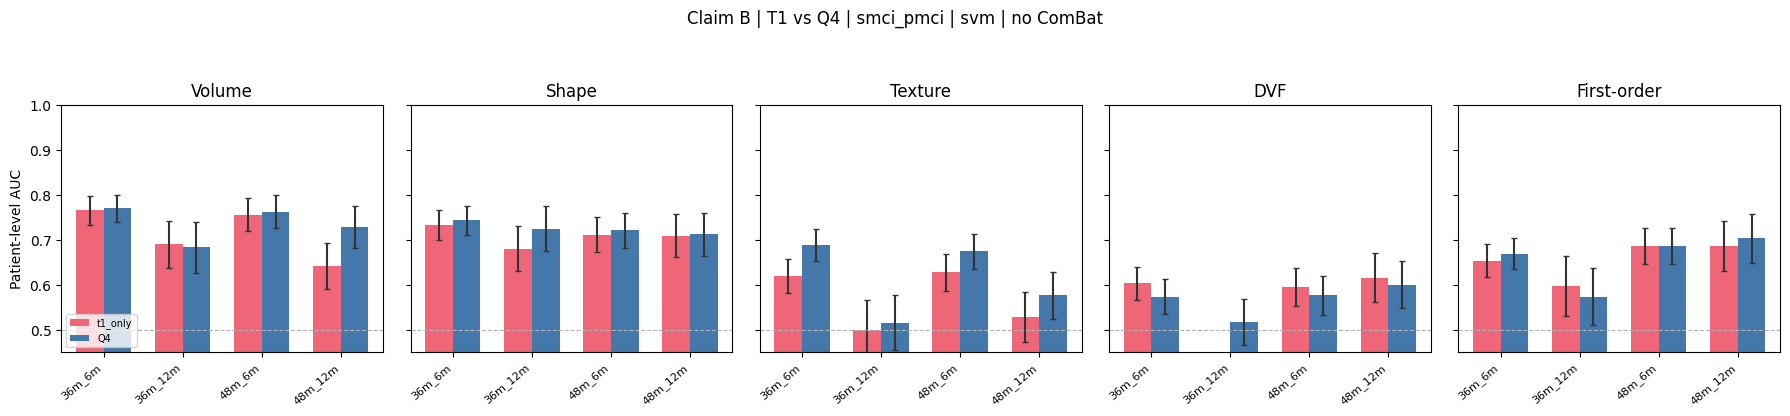

Salvo: artigo/figures/cohort_encoding_vs_t1_modalities_boxplot.pdf


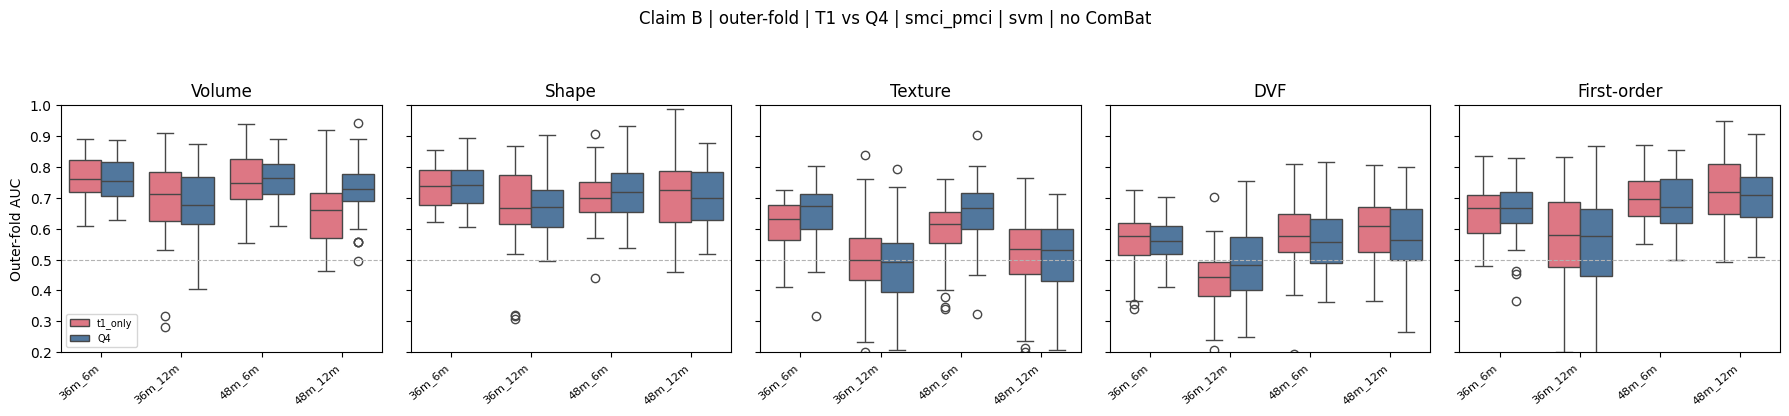


Claim B | recorte vol (gradiente):


,cohort,n_smci,n_pmci,auc_t1,sd_t1,auc_q4,sd_q4,delta_q4_t1,auc_pooled_t1,auc_pooled_q4,...,sens_pos_mean_q4,sens_pos_std_q4,spec_neg_mean_t1,spec_neg_std_t1,spec_neg_mean_q4,spec_neg_std_q4,f1_pos_mean_t1,f1_pos_std_t1,f1_pos_mean_q4,f1_pos_std_q4
0,36m_6m,125,106,0.7655,0.0314,0.7702,0.0303,0.0047,0.7606,0.7499,...,0.6963,0.1289,0.6143,0.1063,0.6592,0.1211,0.7035,0.0684,0.6601,0.0737
5,36m_12m,121,33,0.6899,0.0526,0.6836,0.0573,-0.0063,0.6710,0.6563,...,0.5571,0.2570,0.5813,0.2023,0.6925,0.1381,0.3853,0.1050,0.3924,0.1590
10,48m_6m,73,120,0.7559,0.0368,0.7630,0.0364,0.0071,0.7466,0.7447,...,0.6691,0.1242,0.6415,0.1523,0.6886,0.1359,0.7412,0.0729,0.7144,0.0770
15,48m_12m,72,48,0.6409,0.0512,0.7294,0.0465,0.0885,0.6282,0.7132,...,0.6220,0.1775,0.6529,0.1727,0.6925,0.1483,0.4660,0.1604,0.5884,0.1133


Salvo: artigo/figures/cohort_primary_encoding_vs_t1.pdf


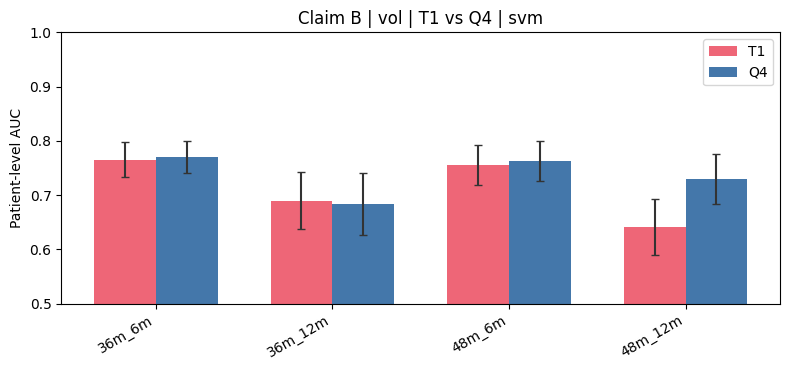

Salvo: artigo/figures/cohort_primary_encoding_boxplot.pdf


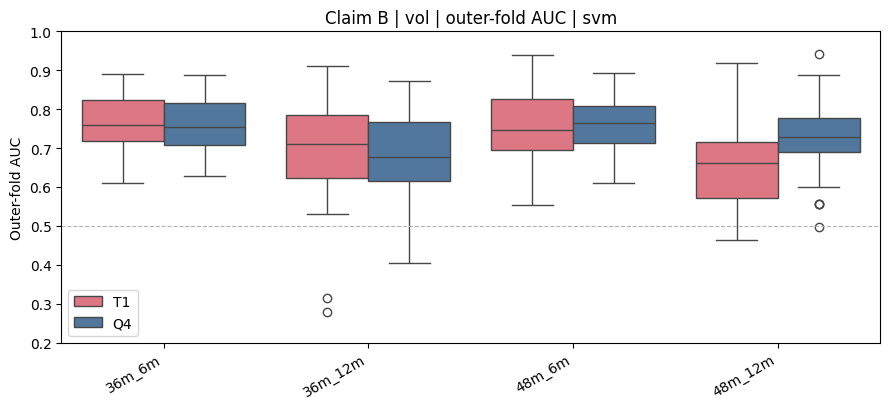

In [7]:
import importlib
import cohort_compare

importlib.reload(cohort_compare)
from cohort_compare import (
    METRIC_PAIRS,
    ABCD_ARMS,
    ABCD_PROTOCOLS,
    build_abcd_contrast_table,
    save_cohort_comparison,
    read_cohort_results,
)

BACKUP_RE = r"backup|_cn_ad"
# métricas do summary (fold-level) + pooled; patient AUC tratado à parte
_SUMMARY_METRIC_COLS = ["auc_pooled"] + [c for pair in METRIC_PAIRS for c in pair]
# só gaps 6m / 12m (9m fora do paper) + soft opcional no rebuild
COHORT_ORDER = [c for c in (
    "36m_6m", "36m_12m", "48m_6m", "48m_12m",
) if c in COHORTS_COMPARE]
INCLUDE_SOFT_IN_REBUILD = True  # 48m_6m_soft_False se existir
REBUILD_COHORTS = list(COHORTS_COMPARE) + (
    list(COHORTS_COMPARE_SOFT) if INCLUDE_SOFT_IN_REBUILD else []
)


def _drop_backup_rows(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "source_file" not in df.columns:
        return df
    return df.loc[
        ~df["source_file"].astype(str).str.contains(BACKUP_RE, regex=True, na=False)
    ].copy()


REBUILD_COMPARE = False  # True = re-bootstrap completo (lento); preferir CLI terminal

if not COHORTS_COMPARE:
    print("Nenhum cohort com ablation_results_t1_only/ — rode 5_ablation antes.")
else:
    p_res = COMPARE_DIR / "cohort_results.csv"
    p_feat = COMPARE_DIR / "cohort_features_long.csv"
    p_abcd = COMPARE_DIR / "ablation_ABCD_grid.csv"
    if REBUILD_COMPARE or not p_res.is_file():
        print("Cohorts:", REBUILD_COHORTS)
        print("ABCD protocols:", ABCD_PROTOCOLS)
        p_res, p_feat, cohort_results, cohort_features = save_cohort_comparison(
            REBUILD_COHORTS,
            COMPARE_DIR,
            cohorts_root=COHORTS_DIR,
            n_boot=N_BOOT_AUC,
            write_abcd=True,
        )
    else:
        print(f"Carrega cache: {p_res} (REBUILD_COMPARE=False)")
        cohort_results = read_cohort_results(p_res)
        cohort_features = pd.read_csv(p_feat) if p_feat.is_file() else pd.DataFrame()

    cohort_results = _drop_backup_rows(cohort_results)
    if not cohort_features.empty and "source_file" in cohort_features.columns:
        cohort_features = _drop_backup_rows(cohort_features)
    # cache: restringe às coortes do rebuild (4 + soft se incluído)
    _keep = set(REBUILD_COHORTS)
    cohort_results = cohort_results.loc[
        cohort_results["cohort"].astype(str).isin(_keep)
    ].copy()
    if not cohort_features.empty and "cohort" in cohort_features.columns:
        cohort_features = cohort_features.loc[
            cohort_features["cohort"].astype(str).isin(_keep)
        ].copy()
    if "with_combat" in cohort_results.columns:
        cohort_results["with_combat"] = cohort_results["with_combat"].map(
            lambda x: str(x).strip().lower() in ("1", "true", "yes")
        )
    print(f"Usando {len(cohort_results)} linhas results (sem backup/_cn_ad; cohorts={sorted(_keep)})")
    print(f"Features: {len(cohort_features)} linhas")
    _abcd_in = [
        p for p in ABCD_PROTOCOLS
        if (cohort_results["protocol"].astype(str) == p).any()
    ]
    print(f"ABCD protocols in cohort_results: {_abcd_in}")

    # tabela ABCD (cache ou rebuild); regenera a partir de results se CSV antigo
    if p_abcd.is_file() and not REBUILD_COMPARE:
        abcd_grid = pd.read_csv(p_abcd)
        print(f"Carrega ABCD grid: {p_abcd} ({len(abcd_grid)} linhas)")
    else:
        abcd_grid = build_abcd_contrast_table(cohort_results)
        if not abcd_grid.empty:
            abcd_grid.to_csv(p_abcd, index=False)
            print(f"Salvo ABCD grid: {p_abcd} ({len(abcd_grid)} linhas)")
    if not abcd_grid.empty:
        display(abcd_grid.round(4))


    # ── t1 / Q4 × modality × cohort (svm, no ComBat, smci_pmci) ──
    PROTO_ENC = ("t1_only", "t1_d21_d32")
    base = cohort_results.query(
        "task == @CFG.task_primary and model_key == @CFG.model_primary "
        "and with_combat == False and protocol in @PROTO_ENC"
    ).copy()
    key = ["cohort", "protocol", "modality"]
    base = base.sort_values(key).drop_duplicates(subset=key, keep="last")

    meta_cols = ["cohort", "t_janela", "t_imagens", "n_smci", "n_pmci", "modality"]
    sum_cols = [c for c in _SUMMARY_METRIC_COLS if c in base.columns]

    def _enc_slice(proto: str, suffix: str, *, with_meta: bool) -> pd.DataFrame:
        cols = (meta_cols if with_meta else ["cohort", "modality"]) + [
            "auc_patient_mean", "auc_patient_std", *sum_cols,
        ]
        rename = {
            "auc_patient_mean": f"auc_{suffix}",
            "auc_patient_std": f"sd_{suffix}",
            **{c: f"{c}_{suffix}" for c in sum_cols},
        }
        return base.query("protocol == @proto")[cols].rename(columns=rename)

    t1 = _enc_slice("t1_only", "t1", with_meta=True)
    q4 = _enc_slice("t1_d21_d32", "q4", with_meta=False)

    cmp = t1.merge(q4, on=["cohort", "modality"], how="inner")
    cmp["delta_q4_t1"] = cmp["auc_q4"] - cmp["auc_t1"]
    cmp["modality"] = pd.Categorical(cmp["modality"], categories=MOD_ORDER, ordered=True)
    cmp["cohort"] = pd.Categorical(cmp["cohort"], categories=COHORT_ORDER, ordered=True)
    cmp = cmp.sort_values(["cohort", "modality"]).reset_index(drop=True)

    _auc_block = ["auc_t1", "sd_t1", "auc_q4", "sd_q4", "delta_q4_t1"]
    _extra_block = []
    for mean_c, std_c in [("auc_pooled", None), *METRIC_PAIRS]:
        for sfx in ("t1", "q4"):
            m = f"{mean_c}_{sfx}"
            if m in cmp.columns:
                _extra_block.append(m)
            if std_c is not None:
                s = f"{std_c}_{sfx}"
                if s in cmp.columns:
                    _extra_block.append(s)
    _show_cols = [
        c for c in [*meta_cols, *_auc_block, *_extra_block] if c in cmp.columns
    ]

    _dup_n = int(cmp.duplicated(["cohort", "modality"]).sum())
    if _dup_n:
        print(f"aviso: {_dup_n} linhas duplicadas (cohort, modality) — keep=last")
        print(cmp.loc[cmp.duplicated(["cohort", "modality"], keep=False), ["cohort", "modality"]])
    cmp = cmp.drop_duplicates(subset=["cohort", "modality"], keep="last")

    pivot_t1 = cmp.pivot_table(index="cohort", columns="modality", values="auc_t1", aggfunc="first")
    pivot_q4 = cmp.pivot_table(index="cohort", columns="modality", values="auc_q4", aggfunc="first")
    pivot_d = cmp.pivot_table(index="cohort", columns="modality", values="delta_q4_t1", aggfunc="first")

    COMPARE_DIR.mkdir(parents=True, exist_ok=True)
    enc_path = COMPARE_DIR / "encoding_vs_t1_by_modality.csv"
    cmp.to_csv(enc_path, index=False)
    print(f"CSV: {enc_path}")
    print("Δ(Q4−T1) patient AUC:")
    display(pivot_d.round(3))

    mods_plot = [m for m in MOD_ORDER if m in cmp["modality"].astype(str).unique()]
    n_mod = len(mods_plot)
    if n_mod and len(cmp):
        fig, axes = plt.subplots(
            1, n_mod, figsize=(3.6 * n_mod, 4.2), sharey=True, squeeze=False,
        )
        x = np.arange(len(COHORT_ORDER))
        w = 0.35
        for ax, mod in zip(axes[0], mods_plot):
            sub = cmp.loc[cmp["modality"] == mod].set_index("cohort").reindex(COHORT_ORDER)
            ax.bar(x - w / 2, sub["auc_t1"], w, yerr=sub["sd_t1"],
                   capsize=2, label="t1_only", color="#EE6677", ecolor="#333333")
            ax.bar(x + w / 2, sub["auc_q4"], w, yerr=sub["sd_q4"],
                   capsize=2, label="Q4", color="#4477AA", ecolor="#333333")
            ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
            ax.set_xticks(x)
            ax.set_xticklabels(COHORT_ORDER, rotation=40, ha="right", fontsize=8)
            ax.set_title(MOD_LABELS.get(mod, mod))
            ax.set_ylim(0.45, 1.0)
            if ax is axes[0, 0]:
                ax.set_ylabel("Patient-level AUC")
                ax.legend(fontsize=7, loc="lower left")
        fig.suptitle(
            f"Claim B | T1 vs Q4 | {CFG.task_primary} | {CFG.model_primary} | no ComBat",
        )
        fig.tight_layout(rect=[0, 0, 1, 0.92])
        save_fig(fig, "cohort_encoding_vs_t1_modalities")
        plt.show()

        _proto_dirs = {
            "t1_only": "ablation_results_t1_only",
            "Q4": "ablation_results_d21d32",
        }
        _enc_colors = {"t1_only": "#EE6677", "Q4": "#4477AA"}
        rows_bp = []
        for mod in mods_plot:
            for cohort in COHORT_ORDER:
                for label, dirname in _proto_dirs.items():
                    path = COHORTS_DIR / cohort / dirname / mod / "ablation_results_all.csv"
                    if not path.is_file():
                        continue
                    try:
                        sub = filter_ablation_config(
                            pd.read_csv(path),
                            task=CFG.task_primary,
                            modality=mod,
                            model_key=CFG.model_primary,
                            with_combat=CFG.with_combat,
                            selection_mode=CFG.selection_mode,
                        )
                    except ValueError:
                        continue
                    for v in sub["auc"].astype(float):
                        rows_bp.append({
                            "cohort": cohort,
                            "modality": mod,
                            "encoding": label,
                            "auc": float(v),
                        })
        bp = pd.DataFrame(rows_bp)
        if bp.empty:
            print("boxplot multi-mod: sem dados")
        else:
            n_mod = len(mods_plot)
            fig, axes = plt.subplots(
                1, n_mod, figsize=(3.6 * n_mod, 4.2), sharey=True, squeeze=False,
            )
            for ax, mod in zip(axes[0], mods_plot):
                sub = bp.loc[bp["modality"] == mod]
                sns.boxplot(
                    data=sub, x="cohort", y="auc", hue="encoding",
                    order=COHORT_ORDER, hue_order=list(_proto_dirs),
                    palette=_enc_colors, ax=ax,
                )
                ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
                ax.set_title(MOD_LABELS.get(mod, mod))
                ax.set_xlabel("")
                ax.set_ylim(0.2, 1.0)
                plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
                if ax is axes[0, 0]:
                    ax.set_ylabel("Outer-fold AUC")
                    ax.legend(fontsize=7, loc="lower left")
                else:
                    leg = ax.get_legend()
                    if leg is not None:
                        leg.remove()
            fig.suptitle(
                f"Claim B | outer-fold | T1 vs Q4 | {CFG.task_primary} | "
                f"{CFG.model_primary} | no ComBat",
            )
            fig.tight_layout(rect=[0, 0, 1, 0.92])
            save_fig(fig, "cohort_encoding_vs_t1_modalities_boxplot")
            plt.show()

    primary = cmp.query("modality == @CFG.modality_primary").copy()
    print(f"\nClaim B | recorte {CFG.modality_primary} (gradiente):")
    _prim_cols = [
        c for c in [
            "cohort", "n_smci", "n_pmci",
            "auc_t1", "sd_t1", "auc_q4", "sd_q4", "delta_q4_t1",
            *_extra_block,
        ] if c in primary.columns
    ]
    if len(primary):
        display(primary[_prim_cols].round(4))
        fig, ax = plt.subplots(figsize=(8, 3.8))
        x = np.arange(len(primary))
        w = 0.35
        ax.bar(x - w / 2, primary["auc_t1"], w, yerr=primary["sd_t1"],
               capsize=3, label="T1", color="#EE6677", ecolor="#333333")
        ax.bar(x + w / 2, primary["auc_q4"], w, yerr=primary["sd_q4"],
               capsize=3, label="Q4", color="#4477AA", ecolor="#333333")
        ax.set_xticks(x)
        ax.set_xticklabels(primary["cohort"].astype(str), rotation=30, ha="right")
        ax.set_ylabel("Patient-level AUC")
        ax.set_ylim(0.5, 1.0)
        ax.legend()
        ax.set_title(
            f"Claim B | {CFG.modality_primary} | T1 vs Q4 | {CFG.model_primary}"
        )
        plt.tight_layout()
        save_fig(fig, "cohort_primary_encoding_vs_t1")
        plt.show()

        _proto_dirs = {
            "T1": "ablation_results_t1_only",
            "Q4": "ablation_results_d21d32",
        }
        _enc_colors = {"T1": "#EE6677", "Q4": "#4477AA"}
        rows_bp = []
        for cohort in primary["cohort"].astype(str):
            for label, dirname in _proto_dirs.items():
                path = (
                    COHORTS_DIR / cohort / dirname
                    / CFG.modality_primary / "ablation_results_all.csv"
                )
                if not path.is_file():
                    continue
                try:
                    sub = filter_ablation_config(
                        pd.read_csv(path),
                        task=CFG.task_primary,
                        modality=CFG.modality_primary,
                        model_key=CFG.model_primary,
                        with_combat=CFG.with_combat,
                        selection_mode=CFG.selection_mode,
                    )
                except ValueError:
                    continue
                for v in sub["auc"].astype(float):
                    rows_bp.append({"cohort": cohort, "encoding": label, "auc": float(v)})
        bp = pd.DataFrame(rows_bp)
        fig, ax = plt.subplots(figsize=(9, 4.2))
        if bp.empty:
            ax.set_title("sem AUCs outer-fold para boxplot")
        else:
            order = [c for c in COHORT_ORDER if c in set(bp["cohort"])]
            sns.boxplot(
                data=bp, x="cohort", y="auc", hue="encoding",
                order=order, hue_order=list(_proto_dirs),
                palette=_enc_colors, ax=ax,
            )
            ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
            ax.set_ylabel("Outer-fold AUC")
            ax.set_xlabel("")
            ax.set_ylim(0.2, 1.0)
            ax.legend(title="", loc="lower left")
            ax.set_title(
                f"Claim B | {CFG.modality_primary} | outer-fold AUC | {CFG.model_primary}"
            )
            plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
        plt.tight_layout()
        save_fig(fig, "cohort_primary_encoding_boxplot")
        plt.show()


### Ablação ABCD (revisor 2)

Lê `ablation_ABCD_grid.csv` do rebuild. Contrastes:
- **B − B0** = efeito ÷Δt (mesma estrutura consecutivos)
- **C/D − B0** = taxa global / OLS vs Q4 abs
- **\* − A** = ganho vs baseline

Fig A do paper **não** muda (continua Baseline / Duas visitas / Q4 abs).

In [ ]:
# Heatmap Δ(C − B0) e Δ(B − B0) — ablação temporal (não substitui Fig A)
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

p_abcd = Path("csvs/cohort_comparison/ablation_ABCD_grid.csv")
if not p_abcd.is_file():
    print("Sem ablation_ABCD_grid.csv — rode rebuild CLI após soft_False terminar.")
else:
    abcd = pd.read_csv(p_abcd)
    mods = [m for m in ("vol", "shape", "texture", "firstorder", "disp") if m in set(abcd["modality"].astype(str))]
    cohorts = [c for c in ("36m_6m", "36m_12m", "48m_6m", "48m_12m", "48m_6m_soft_False") if c in set(abcd["cohort"].astype(str))]

    def _heat(col: str, title: str, fname: str) -> None:
        mat = abcd.pivot_table(index="modality", columns="cohort", values=col, aggfunc="last")
        mat = mat.reindex(index=mods, columns=cohorts)
        fig, ax = plt.subplots(figsize=(1.4 * max(len(cohorts), 1) + 2, 3.2))
        im = ax.imshow(mat.to_numpy(dtype=float), cmap="RdBu_r", vmin=-0.08, vmax=0.08, aspect="auto")
        ax.set_xticks(range(len(mat.columns)))
        ax.set_xticklabels(mat.columns, rotation=30, ha="right", fontsize=8)
        ax.set_yticks(range(len(mat.index)))
        ax.set_yticklabels(mat.index)
        ax.set_title(title)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat.iloc[i, j]
                if pd.notna(v):
                    ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()
        save_fig(fig, fname)

    _heat("delta_B_minus_B0", "ABCD | B − B0 (÷Δt vs Q4 abs)", "abcd_delta_B_minus_B0")
    _heat("delta_C_minus_B0", "ABCD | C − B0 (rate02 vs Q4 abs)", "abcd_delta_C_minus_B0")
    _heat("delta_D_minus_A", "ABCD | D − A (OLS vs baseline)", "abcd_delta_D_minus_A")
    # claim vol
    claim = abcd.query("cohort == '48m_6m' and modality == 'vol'")
    if len(claim):
        display(claim.round(4))


In [8]:
# # Late fusion vs teto unimodal (shape T1) e união-baseline — 48m_12m
# CLAIM_COHORT = "48m_12m"
# res = pd.read_csv(COMPARE_DIR / "cohort_results.csv")
# res["with_combat"] = res["with_combat"].map(
#     lambda x: str(x).strip().lower() in ("1", "true", "yes")
# )
# res = res.loc[
#     (res["cohort"].astype(str) == CLAIM_COHORT)
#     & (res["task"].astype(str) == CFG.task_primary)
#     & (res["model_key"].astype(str) == CFG.model_primary)
#     & (res["with_combat"] == False)
# ].copy()


# def _auc(protocol: str, modality: str | None = None) -> tuple[float, float]:
#     sub = res.loc[res["protocol"].astype(str) == protocol]
#     if modality is not None:
#         sub = sub.loc[sub["modality"].astype(str) == modality]
#     if sub.empty:
#         raise KeyError(f"missing {CLAIM_COHORT} {protocol}/{modality}")
#     r = sub.iloc[0]
#     return float(r["auc_patient_mean"]), float(r["auc_patient_std"])


# SPECS = [
#     ("forma t0", "t1_only", "shape", "ceiling"),
#     ("late uniao t0", LATE_ALL_T1, LATE_ALL_T1, "ceiling"),
#     ("late tudo Q4", LATE_ALL_Q4, LATE_ALL_Q4, "pass"),
#     ("late ancora", LATE_ANCORA, LATE_ANCORA, "claim"),
# ]
# COLORS = {
#     "ceiling": "#BBBBBB",
#     "fail": "#EE6677",
#     "pass": "#4477AA",
#     "claim": "#228833",
# }

# rows = [(lab, *_auc(proto, mod), role) for lab, proto, mod, role in SPECS]
# auc_uni = rows[0][1]
# auc_union = rows[1][1]
# print(f"{CLAIM_COHORT} | teto unimodal={auc_uni:.3f} | teto uniao T1={auc_union:.3f}")
# for lab, auc, sd, role in rows:
#     print(f"  {auc:.3f}±{sd:.3f}  {role:7s}  {lab}")

# fig, ax = plt.subplots(figsize=(6.8, 4.2))
# x = np.arange(len(rows))
# ax.bar(
#     x, [r[1] for r in rows], 0.65,
#     yerr=[r[2] for r in rows], capsize=3,
#     color=[COLORS[r[3]] for r in rows], ecolor="#333333",
#     edgecolor=["black" if r[3] == "claim" else "none" for r in rows],
#     linewidth=1.2,
# )
# for i, (_, auc, sd, _) in enumerate(rows):
#     ax.text(i, auc + sd + 0.008, f"{auc:.3f}", ha="center", va="bottom", fontsize=8)
# ax.set_xticks(x)
# ax.set_xticklabels([r[0] for r in rows], rotation=20, ha="right")
# ax.set_ylabel("Patient-level AUC")
# ax.set_ylim(0.50, 0.95)
# ax.axhline(auc_uni, color="0.45", ls="--", lw=1.0, zorder=0)
# ax.axhline(auc_union, color="0.15", ls="-", lw=1.0, zorder=0)
# plt.tight_layout()
# # save_fig(fig, "fusion_vs_ceilings_48m12")


48m_6m | teto unimodal=0.712 | teto uniao T1=0.777
  late T1 winner: late__t1_vol__t1_shape__t1_disp__t1_firstorder
  late Q4 winner: late__t1_shape__t1_d21d32_vol__t1_d21d32_disp__t1_d21d32_firstorder
  0.712±0.039  ceiling  Teto baseline
  0.777±0.035  ceiling  União baseline
  0.825±0.033  claim    União longitudinal
Salvo: artigo/figures/fusion_vs_ceilings_48m12.pdf


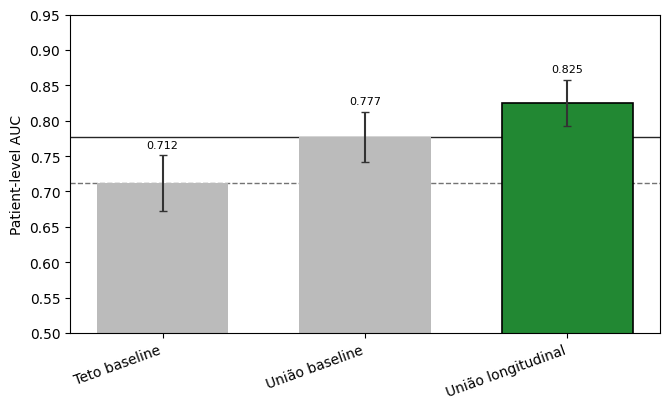

In [9]:
import pandas as pd


# Late fusion vs teto unimodal (shape T1) e melhor união-baseline — 48m_12m
# Teto 1 = shape t1_only. Teto 2 = argmax late só T1. Claim = argmax late com Q4.
CLAIM_COHORT = "48m_6m"
res = pd.read_csv(COMPARE_DIR / "cohort_results.csv")
res["with_combat"] = res["with_combat"].map(
    lambda x: str(x).strip().lower() in ("1", "true", "yes")
)
res = res.loc[
    (res["cohort"].astype(str) == CLAIM_COHORT)
    & (res["task"].astype(str) == CFG.task_primary)
    & (res["model_key"].astype(str) == CFG.model_primary)
    & (res["with_combat"] == False)
].copy()


def _auc(protocol: str, modality: str | None = None) -> tuple[float, float]:
    sub = res.loc[res["protocol"].astype(str) == protocol]
    if modality is not None:
        sub = sub.loc[sub["modality"].astype(str) == modality]
    if sub.empty:
        raise KeyError(f"missing {CLAIM_COHORT} {protocol}/{modality}")
    r = sub.iloc[0]
    return float(r["auc_patient_mean"]), float(r["auc_patient_std"])


def _best_late(sub: pd.DataFrame, tag: str) -> pd.Series:
    if sub.empty:
        raise KeyError(f"sem late {tag} em cohort_results.csv")
    return sub.sort_values("auc_patient_mean", ascending=False).iloc[0]


late = res.loc[res["protocol"].astype(str).str.startswith("late__")].copy()
# só uniões de 5 famílias: late = late.loc[late["protocol"].str.count("__") == 5]
t1_late = late.loc[~late["protocol"].astype(str).str.contains("d21d32")]
q4_late = late.loc[late["protocol"].astype(str).str.contains("d21d32")]
best_t1 = _best_late(t1_late, "T1")
best_q4 = _best_late(q4_late, "Q4/misto")

auc_uni, sd_uni = _auc("t1_only", "shape")
auc_union, sd_union = float(best_t1["auc_patient_mean"]), float(best_t1["auc_patient_std"])
auc_best, sd_best = float(best_q4["auc_patient_mean"]), float(best_q4["auc_patient_std"])
role = "claim" if auc_best > max(auc_uni, auc_union) else "fail"

COLORS = {
    "ceiling": "#BBBBBB",
    "fail": "#EE6677",
    "pass": "#4477AA",
    "claim": "#228833",
}
rows = [
    ("Teto baseline", auc_uni, sd_uni, "ceiling"),
    ("União baseline", auc_union, sd_union, "ceiling"),
    ("União longitudinal", auc_best, sd_best, role),
]

print(f"{CLAIM_COHORT} | teto unimodal={auc_uni:.3f} | teto uniao T1={auc_union:.3f}")
print("  late T1 winner:", best_t1["protocol"])
print("  late Q4 winner:", best_q4["protocol"])
for lab, auc, sd, r in rows:
    print(f"  {auc:.3f}±{sd:.3f}  {r:7s}  {lab}")

fig, ax = plt.subplots(figsize=(6.8, 4.2))
x = np.arange(len(rows))
ax.bar(
    x, [r[1] for r in rows], 0.65,
    yerr=[r[2] for r in rows], capsize=3,
    color=[COLORS[r[3]] for r in rows], ecolor="#333333",
    edgecolor=["black" if r[3] == "claim" else "none" for r in rows],
    linewidth=1.2,
)
for i, (_, auc, sd, _) in enumerate(rows):
    ax.text(i, auc + sd + 0.008, f"{auc:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in rows], rotation=20, ha="right")
ax.set_ylabel("Patient-level AUC")
ax.set_ylim(0.50, 0.95)
ax.axhline(auc_uni, color="0.45", ls="--", lw=1.0, zorder=0)
ax.axhline(auc_union, color="0.15", ls="-", lw=1.0, zorder=0)
plt.tight_layout()
save_fig(fig, "fusion_vs_ceilings_48m12")

# V1 — figuras do `artigo_v1.tex`

**Independente** da seção acima. Rode só a célula **V1 setup** abaixo; depois edite `# ── textos ──` e rode cada figura.

Fonte: `csvs/cohort_comparison/cohort_results.csv` (+ summaries soft / OOF para ROC).


In [1]:
# V1 setup — autocontido (não precisa da célula de imports acima)
import sys
from pathlib import Path

_MOD = Path.cwd() / "modules"
if str(_MOD) not in sys.path:
    sys.path.insert(0, str(_MOD))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve

from ablation_analysis import prepare_ablation_df, explode_patient_predictions

# ── paths / knobs ──
SAVE_FIGS = True
ARTIGO_DIR = Path("Artigo 1 pgirardi")
FIG_DIR = ARTIGO_DIR / "figures"
COHORTS_DIR = Path("csvs/cohorts")
COMPARE_DIR = Path("csvs/cohort_comparison")
N_BOOT_AUC = 2000

MODS_V1 = ["vol", "shape", "texture", "disp", "firstorder"]
MOD_LAB_V1 = {
    "vol": "Volume",
    "shape": "Forma",
    "texture": "Textura",
    "disp": "Desloc.",
    "firstorder": "1ª ordem",
}
PROTO_LAB_V1 = {
    "t1_only": "Baseline",
    "t1_r10": "2 visits",
    "t1_r10_r21": "3v rates",
    "t1_ols": "3v OLS",
}
PROTO_LAB_ABCD = {
    "t1_only": "A baseline",
    "t1_d21_d32": "B0 Q4 abs",
    "t1_r10": "2v R10",
    "t1_r10_r21": "B taxas",
    "t1_rate02": "C rate02",
    "t1_ols": "D OLS",
}
COHORTS_V1 = ["36m_6m", "36m_12m", "48m_6m", "48m_12m"]
CLAIM_V1 = "48m_6m"


def save_fig(fig, name: str) -> None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    path = FIG_DIR / f"{name}.pdf"
    if SAVE_FIGS:
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Salvo:", path)
    plt.show()
    plt.close(fig)


def bootstrap_auc_std(y, scores, *, n_boot: int = N_BOOT_AUC, seed: int = 0) -> float:
    y = np.asarray(y, dtype=int)
    scores = np.asarray(scores, dtype=float)
    rng = np.random.default_rng(seed)
    aucs: list[float] = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), size=len(y))
        yb, sb = y[idx], scores[idx]
        if len(np.unique(yb)) < 2:
            continue
        aucs.append(float(roc_auc_score(yb, sb)))
    if not aucs:
        return float("nan")
    return float(np.std(aucs, ddof=0))


def patient_oof_scores(results_all: Path) -> pd.DataFrame:
    df = prepare_ablation_df(pd.read_csv(results_all))
    m = (df["task"] == "smci_pmci") & (df["model_key"] == "svm")
    if "with_combat" in df.columns:
        m &= ~df["with_combat"].astype(bool)
    df = df.loc[m]
    pat = explode_patient_predictions(df)
    return pat.groupby("ID_PT", as_index=False).agg(y=("y", "first"), score=("score", "mean"))


CR_PATH = COMPARE_DIR / "cohort_results.csv"
cr = pd.read_csv(CR_PATH)
uni_v1 = cr[
    (cr["task"] == "smci_pmci")
    & (cr["model_key"] == "svm")
    & (cr["with_combat"] == False)
    & (cr["modality"].isin(MODS_V1))
    & (cr["protocol"].isin(PROTO_LAB_V1))
].copy()
late_v1 = cr[
    (cr["cohort"] == CLAIM_V1)
    & (cr["task"] == "smci_pmci")
    & (cr["model_key"] == "svm")
    & (cr["with_combat"] == False)
    & (cr["protocol"].astype(str).str.startswith("late__"))
].copy()
print(f"uni_v1={len(uni_v1)} late_v1={len(late_v1)} | FIG_DIR={FIG_DIR}")


uni_v1=60 late_v1=237 | FIG_DIR=Artigo 1 pgirardi/figures


### Fig A — `fig_a_encoding_4cohorts.pdf`

4 painéis (coortes) × 5 famílias × 4 barras (T1 / R10 / B taxas / D OLS).


Salvo: Artigo 1 pgirardi/figures/fig_a_encoding_4cohorts.pdf


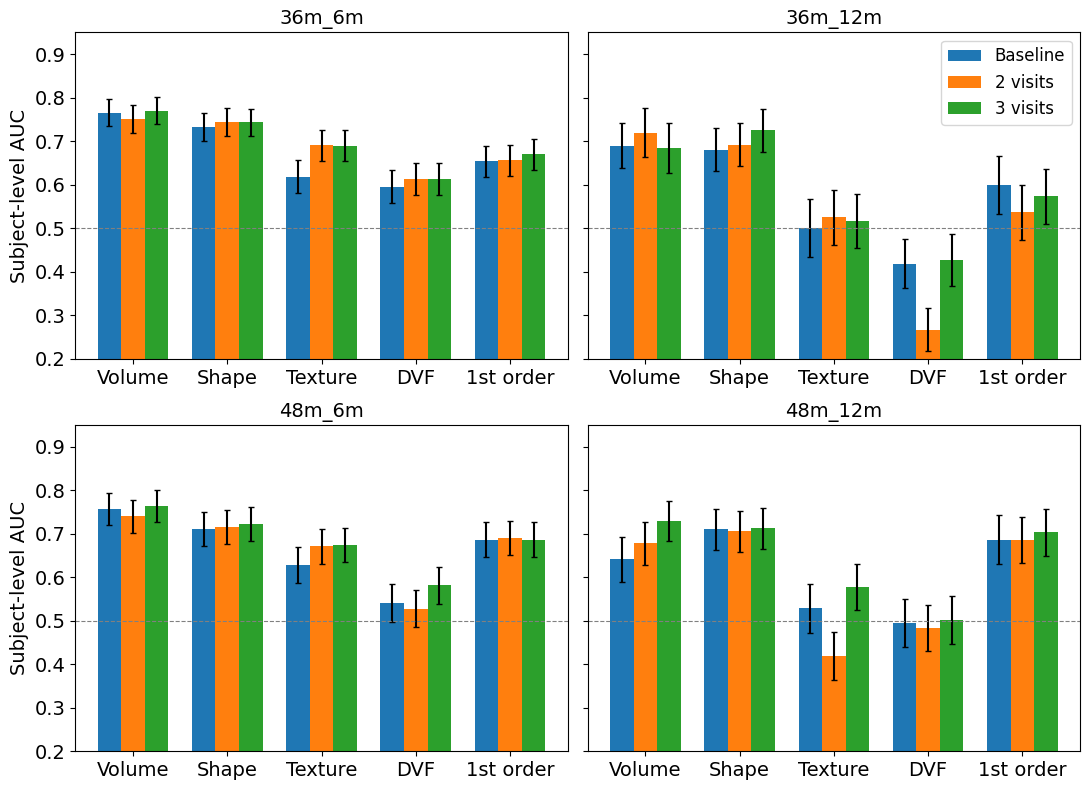

In [2]:
# ── textos (Fig A) ──
TITLE = ""
YLABEL = "Subject-level AUC"
LEGEND_T1, LEGEND_R10, LEGEND_B, LEGEND_D = "Baseline", "2 visits", "3v rates", "3v OLS"
YLIM = (0.2, 0.95)
OUT_NAME = "fig_a_encoding_4cohorts"  # → figures/{OUT_NAME}.pdf

# fontes (pt)
FS_XTICK = 14
FS_YTICK = 14
FS_YLABEL = 14
FS_LEGEND = 11
FS_TITLE = 14

XLAB = {
    "vol": "Volume",
    "shape": "Shape",
    "texture": "Texture",
    "disp": "DVF",
    "firstorder": "1st order",
}

COHORT_TITLES = {
    "36m_6m": "36m_6m",
    "36m_12m": "36m_12m",
    "48m_6m": "48m_6m",
    "48m_12m": "48m_12m",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
proto_order = ["t1_only", "t1_r10", "t1_r10_r21", "t1_ols"]
legends = [LEGEND_T1, LEGEND_R10, LEGEND_B, LEGEND_D]
n_proto = len(proto_order)
w = 0.18
for ax, cohort in zip(axes.ravel(), COHORTS_V1):
    x = np.arange(len(MODS_V1))
    for i, (proto, lab) in enumerate(zip(proto_order, legends)):
        vals, errs = [], []
        for mod in MODS_V1:
            hit = uni_v1[
                (uni_v1["cohort"] == cohort)
                & (uni_v1["modality"] == mod)
                & (uni_v1["protocol"] == proto)
            ]
            vals.append(float(hit.iloc[0]["auc_patient_mean"]) if len(hit) else np.nan)
            errs.append(float(hit.iloc[0]["auc_patient_std"]) if len(hit) else np.nan)
        offset = (i - (n_proto - 1) / 2) * w
        ax.bar(x + offset, vals, w, yerr=errs, capsize=2, label=lab)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [XLAB[m] for m in MODS_V1], rotation=0, ha="center", fontsize=FS_XTICK
    )
    ax.tick_params(axis="y", labelsize=FS_YTICK)
    ax.set_title(COHORT_TITLES.get(cohort, cohort), fontsize=FS_TITLE)
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.set_ylim(*YLIM)

axes[0, 1].legend(loc="upper right", fontsize=FS_LEGEND)
axes[0, 0].set_ylabel(YLABEL, fontsize=FS_YLABEL)
axes[1, 0].set_ylabel(YLABEL, fontsize=FS_YLABEL)
if TITLE:
    fig.suptitle(TITLE, y=1.01)
fig.tight_layout()
save_fig(fig, OUT_NAME)
plt.show()


### Claim — `unimodal_t1_vs_ols_48m6m.pdf`

Barras T1 vs D (OLS) na coorte principal.


Salvo: Artigo 1 pgirardi/figures/unimodal_t1_vs_q4_48m6m.pdf


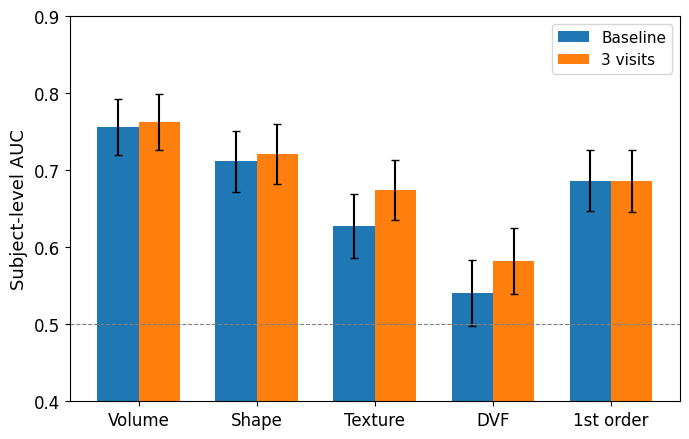

In [3]:
# ── textos (Claim T1 vs D OLS) ──
TITLE = ""
YLABEL = "Subject-level AUC"
LEGEND_T1, LEGEND_D = "Baseline", "3v OLS"
YLIM = (0.4, 0.9)
OUT_NAME = "unimodal_t1_vs_ols_48m6m"

FS_XTICK = 12
FS_YTICK = 12
FS_YLABEL = 13
FS_LEGEND = 11
FS_TITLE = 13

XLAB = {
    "vol": "Volume",
    "shape": "Shape",
    "texture": "Texture",
    "disp": "DVF",
    "firstorder": "1st order",
}

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(MODS_V1))
w = 0.35
for i, (proto, lab) in enumerate([("t1_only", LEGEND_T1), ("t1_ols", LEGEND_D)]):
    vals, errs = [], []
    for mod in MODS_V1:
        hit = uni_v1[
            (uni_v1["cohort"] == CLAIM_V1)
            & (uni_v1["modality"] == mod)
            & (uni_v1["protocol"] == proto)
        ]
        vals.append(float(hit.iloc[0]["auc_patient_mean"]) if len(hit) else np.nan)
        errs.append(float(hit.iloc[0]["auc_patient_std"]) if len(hit) else np.nan)
    ax.bar(x + (i - 0.5) * w, vals, w, yerr=errs, capsize=3, label=lab)
ax.set_xticks(x)
ax.set_xticklabels([XLAB[m] for m in MODS_V1], fontsize=FS_XTICK)
ax.tick_params(axis="y", labelsize=FS_YTICK)
ax.set_ylabel(YLABEL, fontsize=FS_YLABEL)
if TITLE:
    ax.set_title(TITLE, fontsize=FS_TITLE)
ax.legend(fontsize=FS_LEGEND)
ax.set_ylim(*YLIM)
ax.axhline(0.5, color="gray", ls="--", lw=0.8)
fig.tight_layout()
save_fig(fig, OUT_NAME)
plt.show()


### ROC volume — `roc_vol_encodings_48m6m.pdf`

Claim `48m_6m`, família volume. Curvas: Baseline / 2v R10 / 3v rates (B) / 3v OLS (D).


Salvo: Artigo 1 pgirardi/figures/roc_vol_encodings_48m6m.pdf


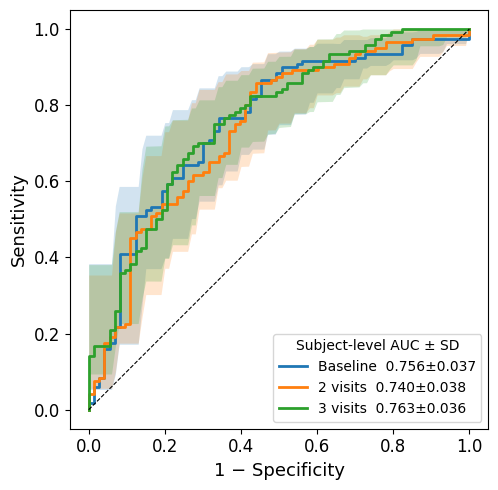

In [4]:
# ── textos (ROC volume) ──
TITLE = ""
XLABEL = "1 − Specificity"
YLABEL = "Sensitivity"
LEGEND_FMT = "{lab}  {auc:.3f}±{sd:.3f}"
LEGEND_TITLE = "Subject-level AUC ± SD"
OUT_NAME = "roc_vol_encodings_48m6m"

# fontes (pt)
FS_XTICK = 12
FS_YTICK = 12
FS_XLABEL = 13
FS_YLABEL = 13
FS_LEGEND = 10
FS_TITLE = 13

# nomes das curvas (lab, pasta, protocol id)
FOLDERS = [
    ("Baseline", "ablation_results_t1_only", "t1_only"),
    ("2 visits", "ablation_results_r10", "t1_r10"),
    ("3v rates", "ablation_results_r10r21", "t1_r10_r21"),
    ("3v OLS", "ablation_results_ols", "t1_ols"),
]

import json as _json

def _interp_tpr(fpr, tpr, grid):
    return np.interp(grid, fpr, tpr, left=0.0, right=1.0)

def _roc_fold_bands(results_all: Path, fpr_grid):
    """TPR médio ± SD entre folds externos (repeat × fold)."""
    df = prepare_ablation_df(pd.read_csv(results_all))
    m = (df["task"] == "smci_pmci") & (df["model_key"] == "svm")
    if "with_combat" in df.columns:
        m &= ~df["with_combat"].astype(bool)
    df = df.loc[m]
    tpr_rows = []
    for _, row in df.iterrows():
        y = np.asarray(_json.loads(row["test_y_true"]), dtype=int)
        s = np.asarray(_json.loads(row["test_scores"]), dtype=float)
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, s)
        tpr_rows.append(_interp_tpr(fpr, tpr, fpr_grid))
    if not tpr_rows:
        raise ValueError(f"sem folds biclasse em {results_all}")
    stack = np.vstack(tpr_rows)
    return stack.mean(axis=0), stack.std(axis=0, ddof=0)

fig, ax = plt.subplots(figsize=(5.5, 5))
base = COHORTS_DIR / CLAIM_V1
fpr_grid = np.linspace(0, 1, 101)
for i, (lab, folder, proto) in enumerate(FOLDERS):
    path = base / folder / "vol" / "ablation_results_all.csv"
    # curva principal = escores OOF agregados por paciente
    p = patient_oof_scores(path)
    fpr, tpr, _ = roc_curve(p["y"], p["score"])
    # faixa = ±SD do TPR entre folds
    tpr_m, tpr_s = _roc_fold_bands(path, fpr_grid)
    hit = uni_v1[
        (uni_v1["cohort"] == CLAIM_V1)
        & (uni_v1["modality"] == "vol")
        & (uni_v1["protocol"] == proto)
    ].iloc[0]
    auc = float(hit["auc_patient_mean"])
    sd = float(hit["auc_patient_std"])
    color = f"C{i}"
    ax.fill_between(
        fpr_grid,
        np.clip(tpr_m - tpr_s, 0, 1),
        np.clip(tpr_m + tpr_s, 0, 1),
        color=color, alpha=0.20, linewidth=0,
    )
    ax.plot(fpr, tpr, color=color, lw=2,
            label=LEGEND_FMT.format(lab=lab, auc=auc, sd=sd))
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel(XLABEL, fontsize=FS_XLABEL)
ax.set_ylabel(YLABEL, fontsize=FS_YLABEL)
ax.tick_params(axis="both", labelsize=FS_XTICK)
if TITLE:
    ax.set_title(TITLE, fontsize=FS_TITLE)
ax.legend(
    loc="lower right",
    fontsize=FS_LEGEND,
    title=LEGEND_TITLE,
    title_fontsize=FS_LEGEND,
)
ax.set_aspect("equal")
fig.tight_layout()
save_fig(fig, OUT_NAME)
plt.show()


### Tetos — `four_ceilings_48m6m.pdf`

Uni T1 / uni D / uni 2v R10 / best late T1-grid / best late D-grid / all-T1 / all-D.


Salvo: Artigo 1 pgirardi/figures/four_ceilings_48m6m.pdf


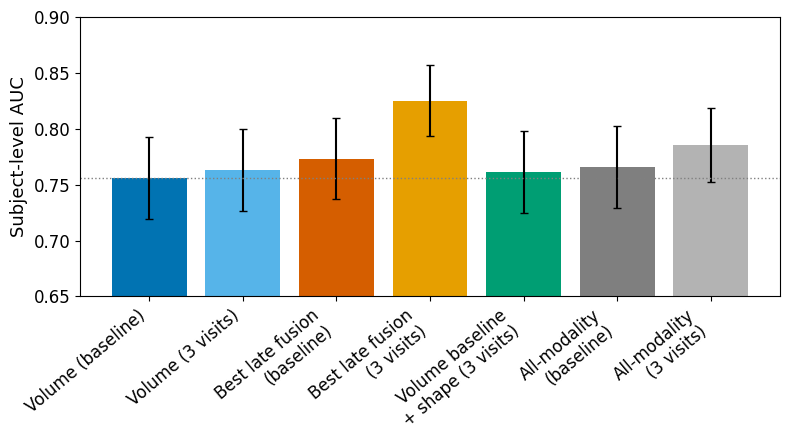

barras: [('Volume (baseline)', 0.7559), ('Volume (3 visits)', 0.763), ('Best late fusion\n(baseline)', 0.7734), ('Best late fusion\n(3 visits)', 0.8253), ('Volume baseline\n+ shape (3 visits)', 0.7613), ('All-modality\n(baseline)', 0.7659), ('All-modality\n(3 visits)', 0.7855)]
âncora proto: late__t1_vol__t1_d21d32_shape | máx grelha: late__t1_shape__t1_d21d32_vol__t1_d21d32_texture__t1_d21d32_firstorder


In [5]:
# ── textos (quatro tetos) ──
TITLE = ""
YLABEL = "Subject-level AUC"
BAR_LABELS = [
    "Best uni\n(baseline)",
    "Best uni\n(3v OLS)",
    "Best uni\n(2 visits)",
    "Best late\n(baseline grid)",
    "Best late\n(3v OLS grid)",
    "All-modality\n(baseline)",
    "All-modality\n(3v OLS)",
]
YLIM = (0.65, 0.90)
OUT_NAME = "four_ceilings_48m6m"
ALL_T1 = "late__t1_vol__t1_shape__t1_texture__t1_disp__t1_firstorder"
ALL_OLS = (
    "late__t1_ols_vol__t1_ols_shape__t1_ols_texture"
    "__t1_ols_disp__t1_ols_firstorder"
)

FS_XTICK = 12
FS_YTICK = 12
FS_YLABEL = 13
FS_TITLE = 13
XTICK_ROT = 40

BAR_COLORS = [
    "#0173B2",  # uni T1
    "#56B4E9",  # uni D
    "#009E73",  # uni R10 (ex-âncora)
    "#D55E00",  # best late T1
    "#E69F00",  # best late D
    "#7F7F7F",  # all-T1
    "#B3B3B3",  # all-D
]

u = uni_v1[uni_v1["cohort"] == CLAIM_V1]
best_t1 = u[u["protocol"] == "t1_only"].sort_values("auc_patient_mean", ascending=False).iloc[0]
best_d = u[u["protocol"] == "t1_ols"].sort_values("auc_patient_mean", ascending=False).iloc[0]
best_r10 = u[u["protocol"] == "t1_r10"].sort_values("auc_patient_mean", ascending=False).iloc[0]

# late: baseline-only grid vs long-D grid (fingerprint contém t1_ols / não)
late_t1_only = late_v1[~late_v1["protocol"].astype(str).str.contains("t1_ols|d21")]
late_d = late_v1[late_v1["protocol"].astype(str).str.contains("t1_ols")]
best_union_t1 = late_t1_only.sort_values("auc_patient_mean", ascending=False).iloc[0]
best_union_d = late_d.sort_values("auc_patient_mean", ascending=False).iloc[0] if len(late_d) else best_union_t1
all_t1 = late_v1.loc[late_v1["protocol"] == ALL_T1].iloc[0]
all_d = late_v1.loc[late_v1["protocol"] == ALL_OLS].iloc[0]

rows = [best_t1, best_d, best_r10, best_union_t1, best_union_d, all_t1, all_d]
vals = [float(r["auc_patient_mean"]) for r in rows]
errs = [float(r["auc_patient_std"]) for r in rows]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(len(BAR_LABELS)), vals, yerr=errs, capsize=3, color=BAR_COLORS)
ax.set_xticks(range(len(BAR_LABELS)))
ax.set_xticklabels(BAR_LABELS, fontsize=FS_XTICK, rotation=XTICK_ROT, ha="right" if XTICK_ROT else "center")
ax.tick_params(axis="y", labelsize=FS_YTICK)
ax.set_ylabel(YLABEL, fontsize=FS_YLABEL)
if TITLE:
    ax.set_title(TITLE, fontsize=FS_TITLE)
ax.set_ylim(*YLIM)
ax.axhline(vals[0], color="gray", ls=":", lw=1)
fig.tight_layout()
save_fig(fig, OUT_NAME)
print("barras:", list(zip(BAR_LABELS, [round(v, 4) for v in vals])))
print("best late T1:", best_union_t1["protocol"], "| best late D:", best_union_d["protocol"])
print("caveat: reportar max grelha no texto se ≠ all-T1/all-D")
plt.show()


### Soft — `soft_true_vs_false_48m6m.pdf`

Soft True (claim) vs Soft False; T1 e D (OLS); 5 famílias.


Salvo: Artigo 1 pgirardi/figures/soft_true_vs_false_48m6m.pdf


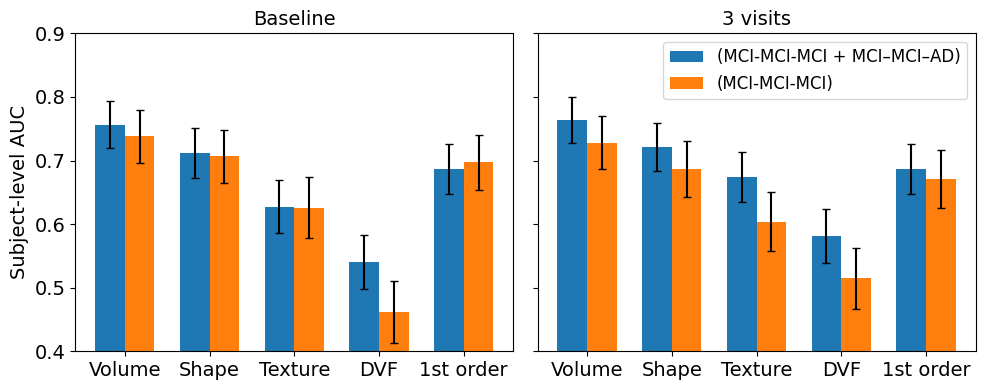

In [6]:
# ── textos (soft) ──
TITLE = ""
YLABEL = "Subject-level AUC"
PANEL_TITLES = {"t1_only": "Baseline", "t1_ols": "3v OLS"}
LEGEND_TRUE = r"(MCI-MCI-MCI + MCI–MCI–AD)"
LEGEND_FALSE = r"(MCI-MCI-MCI)"
OUT_NAME = "soft_true_vs_false_48m6m"
YLIM = (0.40, 0.90)

# fontes (pt)
FS_XTICK = 14
FS_YTICK = 14
FS_YLABEL = 14
FS_LEGEND = 12
FS_TITLE = 14

# eixo x — atributos
XLAB = {
    "vol": "Volume",
    "shape": "Shape",
    "texture": "Texture",
    "disp": "DVF",
    "firstorder": "1st order",
}

ENC_FOLDERS = {"t1_only": "ablation_results_t1_only", "t1_ols": "ablation_results_ols"}

soft_rows = []
for cohort, label in [(CLAIM_V1, LEGEND_TRUE), ("48m_6m_soft_False", LEGEND_FALSE)]:
    base = COHORTS_DIR / cohort
    for enc, folder in ENC_FOLDERS.items():
        for mod in MODS_V1:
            root = base / folder / mod
            summ = root / "ablation_summary.csv"
            allp = root / "ablation_results_all.csv"
            if not summ.exists() or not allp.exists():
                continue
            df = pd.read_csv(summ)
            r = df[(df["task"] == "smci_pmci") & (df["model_key"] == "svm")]
            if r.empty:
                continue
            pat = patient_oof_scores(allp)
            sd = bootstrap_auc_std(
                pat["y"].to_numpy(), pat["score"].to_numpy(),
                seed=hash((cohort, enc, mod)) % 10_000,
            )
            soft_rows.append(
                {"cohort_label": label, "encoding": enc, "modality": mod,
                 "auc": float(r.iloc[0]["auc_patient_mean"]), "sd": float(sd)}
            )
soft = pd.DataFrame(soft_rows)
assert len(soft) == 2 * 2 * len(MODS_V1), f"soft incompleto: {len(soft)} linhas (cwd?)"

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, enc in zip(axes, ["t1_only", "t1_ols"]):
    x = np.arange(len(MODS_V1))
    w = 0.35
    for i, lab in enumerate([LEGEND_TRUE, LEGEND_FALSE]):
        sub = soft[(soft.cohort_label == lab) & (soft.encoding == enc)].set_index("modality")
        vals = [float(sub.loc[m, "auc"]) for m in MODS_V1]
        errs = [float(sub.loc[m, "sd"]) for m in MODS_V1]
        ax.bar(x + (i - 0.5) * w, vals, w, yerr=errs, capsize=3, label=lab)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [XLAB[m] for m in MODS_V1], rotation=0, ha="center", fontsize=FS_XTICK
    )
    ax.tick_params(axis="y", labelsize=FS_YTICK)
    ax.set_title(PANEL_TITLES[enc], fontsize=FS_TITLE)
    ax.set_ylim(*YLIM)
axes[1].legend(fontsize=FS_LEGEND)
axes[0].set_ylabel(YLABEL, fontsize=FS_YLABEL)
if TITLE:
    fig.suptitle(TITLE, y=1.02)
fig.tight_layout()
save_fig(fig, OUT_NAME)
plt.show()


### Heatmaps 4 modelos × 5 famílias — `heatmap_models_t1_48m6m.pdf` / `heatmap_models_ols_48m6m.pdf`

Claim `48m_6m`. Primário: T1 e D (`t1_ols`).


Salvo: Artigo 1 pgirardi/figures/heatmap_models_t1_48m6m.pdf


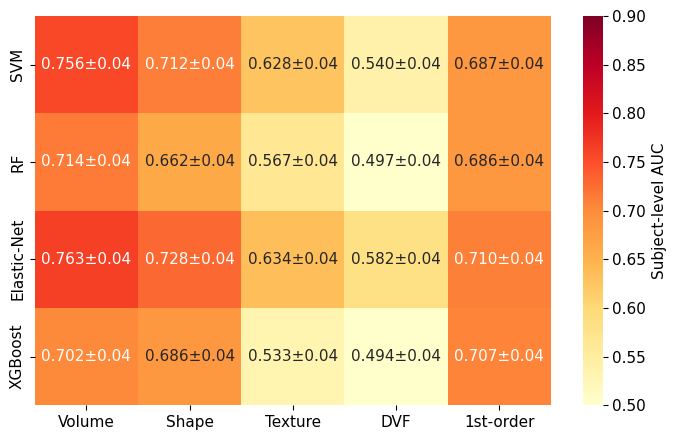

Salvo: Artigo 1 pgirardi/figures/heatmap_models_q4_48m6m.pdf


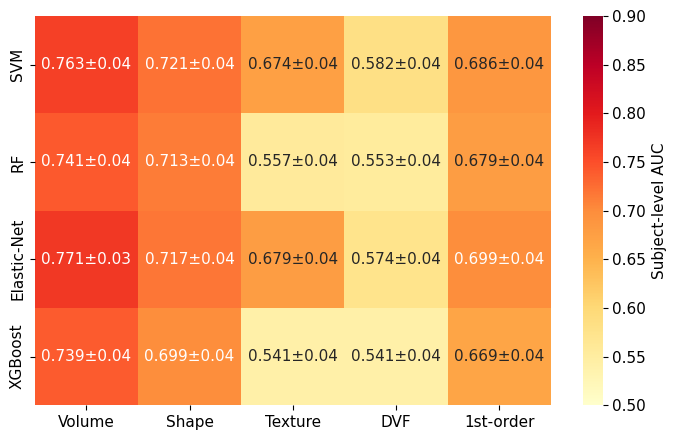

In [10]:
# ── textos (heatmaps modelos) ──
TITLE_T1 = ""
TITLE_OLS = ""
XLABEL = ""
YLABEL = ""
CBAR_LABEL = "Subject-level AUC"
OUT_T1 = "heatmap_models_t1_48m6m"
OUT_OLS = "heatmap_models_ols_48m6m"
CMAP = "YlOrRd"
VMIN, VMAX = 0.50, 0.90
FIGSIZE = (7.0, 4.5)

# fontes (pt)
FS_XTICK = 11
FS_YTICK = 11
FS_XLABEL = 12
FS_YLABEL = 12
FS_ANNOT = 11
FS_TITLE = 12
FS_CBAR = 11

MODELS = ["svm", "rf", "elasticnet", "xgb"]
MODEL_LAB = {
    "svm": "SVM",
    "rf": "RF",
    "elasticnet": "Elastic-Net",
    "xgb": "XGBoost",
}
XLAB = {
    "vol": "Volume",
    "shape": "Shape",
    "texture": "Texture",
    "disp": "DVF",
    "firstorder": "1st-order",
}

ENC_SPECS = [
    (OUT_T1, TITLE_T1, "ablation_results_t1_only"),
    (OUT_OLS, TITLE_OLS, "ablation_results_ols"),
]

import seaborn as sns


def _patient_oof_model(results_all: Path, model_key: str) -> pd.DataFrame:
    df = prepare_ablation_df(pd.read_csv(results_all))
    m = (df["task"] == "smci_pmci") & (df["model_key"] == model_key)
    if "with_combat" in df.columns:
        m &= ~df["with_combat"].astype(bool)
    df = df.loc[m]
    if df.empty:
        raise ValueError(f"sem linhas {model_key} em {results_all}")
    pat = explode_patient_predictions(df)
    return pat.groupby("ID_PT", as_index=False).agg(y=("y", "first"), score=("score", "mean"))


def _heatmap_one(out_name: str, title: str, folder: str) -> None:
    base = COHORTS_DIR / CLAIM_V1 / folder
    auc_w = pd.DataFrame(index=MODELS, columns=MODS_V1, dtype=float)
    sd_w = pd.DataFrame(index=MODELS, columns=MODS_V1, dtype=float)
    for model in MODELS:
        for mod in MODS_V1:
            allp = base / mod / "ablation_results_all.csv"
            summ = base / mod / "ablation_summary.csv"
            if not allp.exists() or not summ.exists():
                print("skip missing", allp)
                continue
            pat = _patient_oof_model(allp, model)
            auc = float(roc_auc_score(pat["y"], pat["score"]))
            sd = bootstrap_auc_std(
                pat["y"].to_numpy(), pat["score"].to_numpy(),
                seed=hash((folder, mod, model)) % 10_000,
            )
            # confere summary se existir
            s = pd.read_csv(summ)
            r = s[(s["task"] == "smci_pmci") & (s["model_key"] == model)]
            if not r.empty:
                auc = float(r.iloc[0]["auc_patient_mean"])
            auc_w.loc[model, mod] = auc
            sd_w.loc[model, mod] = sd
    auc_w = auc_w.rename(index=MODEL_LAB, columns=XLAB)
    sd_w = sd_w.rename(index=MODEL_LAB, columns=XLAB)
    annot = np.asarray(
        [
            ["" if pd.isna(p) else f"{p:.3f}±{s:.2f}" for p, s in zip(auc_w.iloc[i], sd_w.iloc[i])]
            for i in range(len(auc_w))
        ],
        dtype=object,
    ).reshape(auc_w.shape)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    sns.heatmap(
        auc_w.astype(float), annot=annot, fmt="", cmap=CMAP,
        vmin=VMIN, vmax=VMAX, ax=ax,
        annot_kws={"size": FS_ANNOT},
        cbar_kws={"label": CBAR_LABEL},
    )
    ax.set_xlabel(XLABEL, fontsize=FS_XLABEL)
    ax.set_ylabel(YLABEL, fontsize=FS_YLABEL)
    ax.tick_params(axis="x", labelsize=FS_XTICK)
    ax.tick_params(axis="y", labelsize=FS_YTICK)
    if title:
        ax.set_title(title, fontsize=FS_TITLE)
    cbar = ax.collections[0].colorbar
    if cbar is not None:
        cbar.ax.tick_params(labelsize=FS_CBAR)
        cbar.set_label(CBAR_LABEL, fontsize=FS_CBAR)
    fig.tight_layout()
    save_fig(fig, out_name)


for out_name, title, folder in ENC_SPECS:
    _heatmap_one(out_name, title, folder)


### ROC volume × 4 modelos (D OLS) — `roc_vol_models_ols_48m6m.pdf`

Claim `48m_6m`, longitudinal D (`t1_ols`), família volume.


Salvo: Artigo 1 pgirardi/figures/roc_vol_models_q4_48m6m.pdf


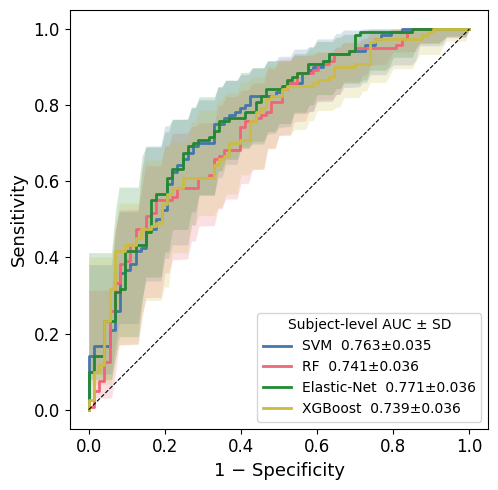

In [ ]:
# ── textos (ROC volume × modelos D OLS) ──
TITLE = ""
XLABEL = "1 − Specificity"
YLABEL = "Sensitivity"
LEGEND_FMT = "{lab}  {auc:.3f}±{sd:.3f}"
LEGEND_TITLE = "Subject-level AUC ± SD"
OUT_NAME = "roc_vol_models_ols_48m6m"
FOLDER = "ablation_results_ols"
MODALITY = "vol"

# fontes (pt)
FS_XTICK = 12
FS_YTICK = 12
FS_XLABEL = 13
FS_YLABEL = 13
FS_LEGEND = 10
FS_TITLE = 13

MODELS = [
    ("svm", "SVM"),
    ("rf", "RF"),
    ("elasticnet", "Elastic-Net"),
    ("xgb", "XGBoost"),
]
# cores opcionais (ordem = MODELS); None = C0..C3
COLORS = ["#4477AA", "#EE6677", "#228833", "#CCBB44"]

import json as _json


def _interp_tpr(fpr, tpr, grid):
    return np.interp(grid, fpr, tpr, left=0.0, right=1.0)


def _patient_oof_model(results_all: Path, model_key: str) -> pd.DataFrame:
    df = prepare_ablation_df(pd.read_csv(results_all))
    m = (df["task"] == "smci_pmci") & (df["model_key"] == model_key)
    if "with_combat" in df.columns:
        m &= ~df["with_combat"].astype(bool)
    df = df.loc[m]
    if df.empty:
        raise ValueError(f"sem linhas {model_key} em {results_all}")
    pat = explode_patient_predictions(df)
    return pat.groupby("ID_PT", as_index=False).agg(y=("y", "first"), score=("score", "mean"))


def _roc_fold_bands(results_all: Path, model_key: str, fpr_grid):
    df = prepare_ablation_df(pd.read_csv(results_all))
    m = (df["task"] == "smci_pmci") & (df["model_key"] == model_key)
    if "with_combat" in df.columns:
        m &= ~df["with_combat"].astype(bool)
    df = df.loc[m]
    tpr_rows = []
    for _, row in df.iterrows():
        y = np.asarray(_json.loads(row["test_y_true"]), dtype=int)
        s = np.asarray(_json.loads(row["test_scores"]), dtype=float)
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, s)
        tpr_rows.append(_interp_tpr(fpr, tpr, fpr_grid))
    if not tpr_rows:
        raise ValueError(f"sem folds biclasse {model_key} em {results_all}")
    stack = np.vstack(tpr_rows)
    return stack.mean(axis=0), stack.std(axis=0, ddof=0)


fig, ax = plt.subplots(figsize=(5.5, 5))
path = COHORTS_DIR / CLAIM_V1 / FOLDER / MODALITY / "ablation_results_all.csv"
summ = COHORTS_DIR / CLAIM_V1 / FOLDER / MODALITY / "ablation_summary.csv"
sdf = pd.read_csv(summ)
fpr_grid = np.linspace(0, 1, 101)

for i, (model_key, lab) in enumerate(MODELS):
    p = _patient_oof_model(path, model_key)
    fpr, tpr, _ = roc_curve(p["y"], p["score"])
    tpr_m, tpr_s = _roc_fold_bands(path, model_key, fpr_grid)
    r = sdf[(sdf["task"] == "smci_pmci") & (sdf["model_key"] == model_key)]
    if r.empty:
        auc = float(roc_auc_score(p["y"], p["score"]))
        sd = bootstrap_auc_std(p["y"].to_numpy(), p["score"].to_numpy(), seed=300 + i)
    else:
        auc = float(r.iloc[0]["auc_patient_mean"])
        sd = bootstrap_auc_std(p["y"].to_numpy(), p["score"].to_numpy(), seed=300 + i)
    color = COLORS[i] if COLORS and i < len(COLORS) else f"C{i}"
    ax.fill_between(
        fpr_grid,
        np.clip(tpr_m - tpr_s, 0, 1),
        np.clip(tpr_m + tpr_s, 0, 1),
        color=color, alpha=0.20, linewidth=0,
    )
    ax.plot(
        fpr, tpr, color=color, lw=2,
        label=LEGEND_FMT.format(lab=lab, auc=auc, sd=sd),
    )

ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel(XLABEL, fontsize=FS_XLABEL)
ax.set_ylabel(YLABEL, fontsize=FS_YLABEL)
ax.tick_params(axis="both", labelsize=FS_XTICK)
if TITLE:
    ax.set_title(TITLE, fontsize=FS_TITLE)
ax.legend(
    loc="lower right",
    fontsize=FS_LEGEND,
    title=LEGEND_TITLE,
    title_fontsize=FS_LEGEND,
)
ax.set_aspect("equal")
fig.tight_layout()
save_fig(fig, OUT_NAME)
plt.show()
